# EDA 1 

Este notebook analiza los comentarios realizados a publicaciones de medios argentinos en Twitter en el periodo de la pandemia, con foco en el discurso xenófobo.

**Dataset:** Aproximanadamente 5.5M comentarios a noticias de 9 medios argentinos, previamente clasificados con etiquetas binarias de odio.

**Proxy de xenofobia:** se usa la etiqueta "RACISM" como proxy de xenofobia, dado que el dataset no tiene una etiqueta específica para ese fenómeno.

**Estructura del análisis:**
1. Carga y filtro de medios argentinos
2. Distribución de noticias y comentarios por medio
3. Distribución por tipo de etiqueta
4. Llamados a la acción por etiqueta
5. Ejemplos de comentarios
6. Co-ocurrencia de etiquetas
6. Análisis temporal
7. Usuarios reincidentes en comentarios racistas
8. Búsqueda de horarios de más odio y racismo


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify as sq

## 1. Carga de datos

El dataset fue generado en `1_create_ar_dataset.ipynb`. Contiene comentarios a publicaciones de medios de comunicación. Las etiquetas de odio son binarias.

In [4]:
file_path = 'data/tweets_con_noticia.csv' #Reemplazar con la ruta del archivo CSV
tw = pd.read_csv(file_path)
tw['date_tweet'] = pd.to_datetime(tw['date_tweet'])

In [5]:
tw.head()

,id,tweet_id_noticia,title,resumen,medio,date_tweet,text,user_id,HATEFUL,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL
0,0,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:03:00.900,@clarincom A mi me preocupa el trabajo.. La ev...,1532596098,0,0,0,0,0,0,0,0,0,0
1,1,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:05:04.500,@clarincom Lo que preocupa. https://t.co/Vmf9V...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
2,2,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:06:03.100,@clarincom Lo que les preocupa. https://t.co/P...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
3,3,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:11:02.300,@clarincom Le recomendaríamos al presidente de...,582286194,0,0,0,0,0,0,0,0,0,0
4,4,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:26:00.600,@clarincom Para salvar al correo de la quiebra...,951552761988034560,0,0,0,0,0,0,0,0,0,0


In [6]:
tw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8569648 entries, 0 to 8569647
Data columns (total 18 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                int64         
 1   tweet_id_noticia  int64         
 2   title             str           
 3   resumen           str           
 4   medio             str           
 5   date_tweet        datetime64[us]
 6   text              str           
 7   user_id           int64         
 8   HATEFUL           int64         
 9   CALLS             int64         
 10  WOMEN             int64         
 11  LGBTI             int64         
 12  RACISM            int64         
 13  CLASS             int64         
 14  POLITICS          int64         
 15  DISABLED          int64         
 16  APPEARANCE        int64         
 17  CRIMINAL          int64         
dtypes: datetime64[us](1), int64(13), str(4)
memory usage: 3.8 GB


In [7]:
#Medios de comunicación presentes en el dataset
tw['medio'].value_counts()

medio
infobae            1691830
LANACION           1574297
clarincom          1486018
elmundoes          1344679
abc_es              811077
latercera           595254
pagina12            221971
cronica             205588
elpaisuy            188608
perfilcom           159860
LaVanguardia        136633
laderechamedios      69944
laderechadiario      65907
izquierdadiario      17982
Name: count, dtype: int64

### 1.1. Filtro de medios argentinos

El dataset original incluye medios de varios países hispanohablantes. Se filtran solo los medios argentinos ya que son los relevantes para el análisis que se busca realizar.

In [8]:
# Filtrar solo medios argentinos
medios_arg = ['LANACION', 'clarincom', 'cronica', 'infobae','izquierdadiario', 'laderechadiario', 'laderechamedios', 'pagina12', 'perfilcom']

tw_arg = tw[tw['medio'].isin(medios_arg)].copy() 

print(f"Nuevo tamaño del dataset: {len(tw_arg):,}")
print(f"Medios incluidos: {sorted(tw_arg['medio'].unique())}")


Nuevo tamaño del dataset: 5,493,397
Medios incluidos: ['LANACION', 'clarincom', 'cronica', 'infobae', 'izquierdadiario', 'laderechadiario', 'laderechamedios', 'pagina12', 'perfilcom']


In [9]:
tw_arg.to_csv('data/tweets_medios_arg.csv', index=False) #Se guarda como csv para poder usarlo en el EDA2

## 2. Distribución de noticias y comentarios por medio


### 2.1. ¿Cuántas noticias y cuántos comentarios tenemos por cada medio ?

In [10]:
# Noticias únicas por medio (cada tweet_id_noticia es una noticia)
noticias_por_medio = (
    tw_arg.dropna(subset=['medio'])
    .groupby('medio')['tweet_id_noticia']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'tweet_id_noticia': 'noticias'})
)

# Comentarios por medio
comentarios_por_medio = (
    tw_arg.dropna(subset=['medio'])
    .groupby('medio')
    .size()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'comentarios'})
)

resumen = noticias_por_medio.merge(comentarios_por_medio, on='medio')
resumen

,medio,noticias,comentarios
0,infobae,98751,1691830
1,clarincom,66267,1486018
2,LANACION,51536,1574297
3,cronica,50316,205588
4,pagina12,29184,221971
5,perfilcom,21056,159860
6,izquierdadiario,7786,17982
7,laderechadiario,2904,65907
8,laderechamedios,2800,69944


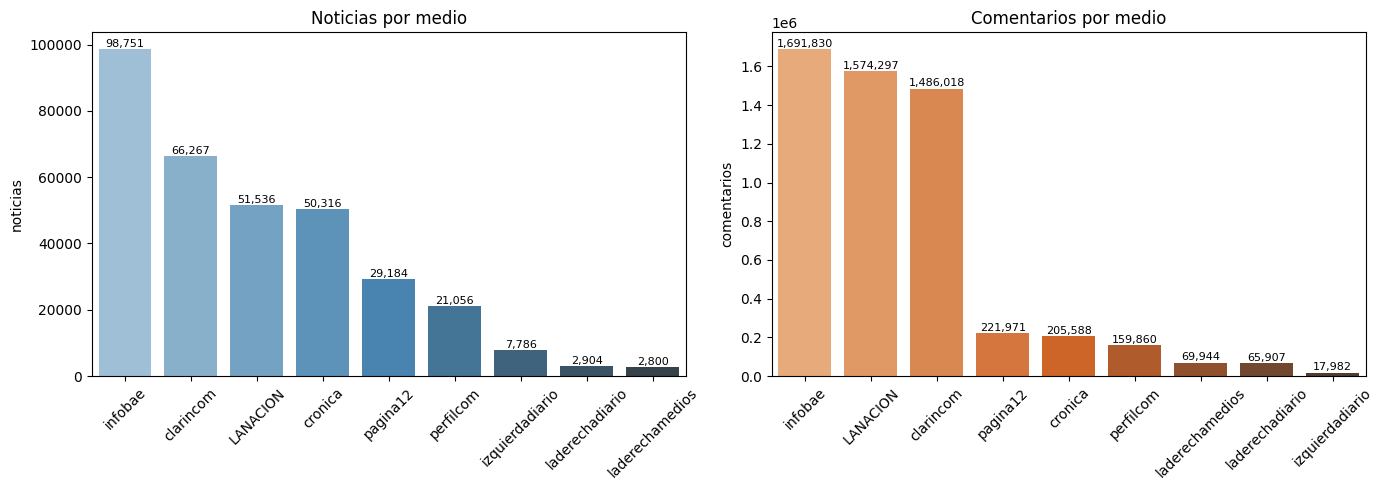

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Barplot de noticias separadas por el medio de comunicación que hizo el tweet
resumen_sorted_n = resumen.sort_values('noticias', ascending=False)
sns.barplot(data=resumen_sorted_n, x='medio', y='noticias', hue='medio', legend=False, palette='Blues_d', ax=axes[0])
axes[0].set_title('Noticias por medio')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches, resumen_sorted_n['noticias']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

# Barplot de comentarios separados por el medio de comunicacion al que se le hizo el comentario
resumen_sorted_c = resumen.sort_values('comentarios', ascending=False)
sns.barplot(data=resumen_sorted_c, x='medio', y='comentarios', hue='medio', legend=False, palette='Oranges_d', ax=axes[1])
axes[1].set_title('Comentarios por medio')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[1].patches, resumen_sorted_c['comentarios']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

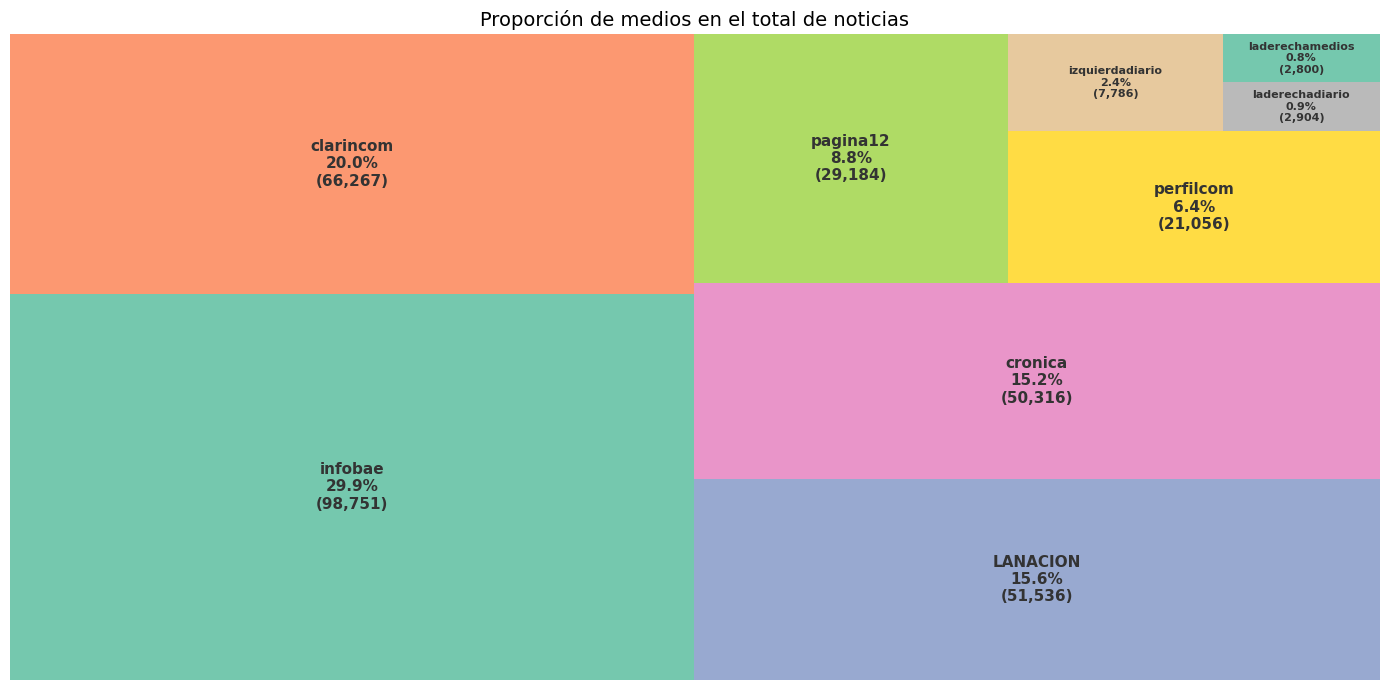

In [12]:
# Proporción de medios en el total de noticias — treemap
resumen_prop = resumen.copy()
resumen_prop['pct_noticias'] = resumen_prop['noticias'] / resumen_prop['noticias'].sum() * 100
resumen_prop = resumen_prop.sort_values('pct_noticias', ascending=False).reset_index(drop=True)

palette = sns.color_palette('Set2', n_colors=len(resumen_prop))

fig, ax = plt.subplots(figsize=(14, 7))

rects = sq.squarify(sq.normalize_sizes(resumen_prop['noticias'], 100, 100), 0, 0, 100, 100)
sq.plot(sizes=resumen_prop['noticias'], label=[''] * len(resumen_prop),
              color=palette, alpha=0.9, ax=ax)

for rect, (_, row) in zip(rects, resumen_prop.iterrows()):
    cx = rect['x'] + rect['dx'] / 2
    cy = rect['y'] + rect['dy'] / 2
    fontsize = 11 if row['pct_noticias'] >= 5 else 8
    label = f"{row['medio']}\n{row['pct_noticias']:.1f}%\n({int(row['noticias']):,})"
    ax.text(cx, cy, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='#333333',
            transform=ax.transData)

ax.set_title('Proporción de medios en el total de noticias', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

### 2.2. Promedio de comentarios por noticia

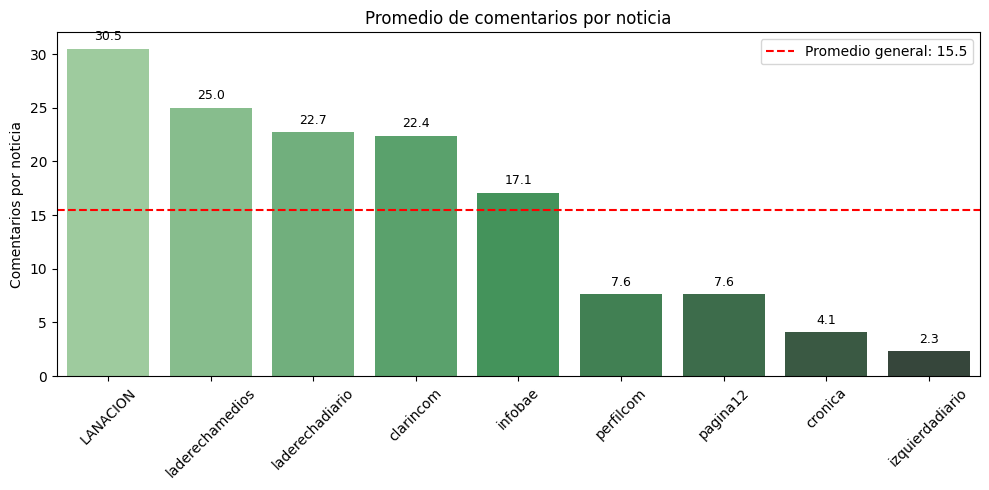

In [13]:
ratio = resumen.copy() #la tabla resumen con cantidad de noticias y comentarios por medio
ratio['comentarios_por_noticia'] = (ratio['comentarios'] / ratio['noticias']).round(1) #l promedio de comentarios por noticia para cada medio 
ratio = ratio[['medio', 'comentarios_por_noticia']].sort_values('comentarios_por_noticia', ascending=False).reset_index(drop=True)

promedio_general = ratio['comentarios_por_noticia'].mean().round(1) 

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ratio, x='medio', y='comentarios_por_noticia', hue='medio', legend=False, palette='Greens_d', ax=ax)
ax.axhline(promedio_general, color='red', linestyle='--', linewidth=1.5, label=f'Promedio general: {promedio_general}')
ax.set_title('Promedio de comentarios por noticia')
ax.set_xlabel('')
ax.set_ylabel('Comentarios por noticia')
ax.tick_params(axis='x', rotation=45)
ax.legend()
for bar, val in zip(ax.patches, ratio['comentarios_por_noticia']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:,.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Podria ser interesante ver que noticia recibio mas comentarios negativos para cada medio y ver de que habla.


### 2.3 Noticia con mas comentarios para cada medio

In [14]:
# Noticia con más comentarios por medio
top_por_medio = (
    tw_arg.groupby(['medio', 'tweet_id_noticia'])
    .agg(
        comentarios=('id', 'count'),
        title=('title', 'first'),
        resumen=('resumen', 'first'),
        fecha=('date_tweet', 'min')
    )
    .reset_index()
    .sort_values('comentarios', ascending=False)
    .groupby('medio')
    .first()
    .reset_index()
    .sort_values('comentarios', ascending=False)
)

# Extraer URL del campo resumen (último token)
top_por_medio['link'] = top_por_medio['resumen'].str.split().str[-1]

for _, row in top_por_medio.iterrows():
    print(f"{'─'*80}")
    print(f"  Medio      : {row['medio']}")
    print(f"  Comentarios: {int(row['comentarios']):,}")
    print(f"  Fecha      : {row['fecha'].date()}")
    print(f"  Titulo     : {row['title']}")
    print(f"  Link       : {row['link']}")
print(f"{'─'*80}")

────────────────────────────────────────────────────────────────────────────────
  Medio      : clarincom
  Comentarios: 4,661
  Fecha      : 2020-12-30
  Titulo     : Aborto legal: así fue el minuto a minuto del debate histórico en el Senado
  Link       : https://t.co/4DzBbeQqd4
────────────────────────────────────────────────────────────────────────────────
  Medio      : LANACION
  Comentarios: 4,593
  Fecha      : 2020-09-18
  Titulo     : Alberto Fernández. "Yo quiero una sociedad como la sueca, la finlandesa, la noruega, donde sí hay condiciones de desarrollo igualitarias"
  Link       : https://t.co/DIEhOqjKc6
────────────────────────────────────────────────────────────────────────────────
  Medio      : infobae
  Comentarios: 4,120
  Fecha      : 2020-08-08
  Titulo     : Laura Azcurra: “Es contradictorio que los actores estamos sin trabajar, pero la gente está en su casa viendo películas y series que hemos hecho nosotros”
  Link       : https://t.co/dVONe12c69
───────────────

In [15]:
# Noticia con más comentarios HATEFUL por medio
top_hateful_por_medio = (
    tw_arg[tw_arg['HATEFUL'] == 1]
    .groupby(['medio', 'tweet_id_noticia'])
    .agg(
        comentarios_hateful=('id', 'count'),
        title=('title', 'first'),
        resumen=('resumen', 'first'),
        fecha=('date_tweet', 'min')
    )
    .reset_index()
    .sort_values('comentarios_hateful', ascending=False)
    .groupby('medio')
    .first()
    .reset_index()
    .sort_values('comentarios_hateful', ascending=False)
)

top_hateful_por_medio['link'] = top_hateful_por_medio['resumen'].str.split().str[-1]

print("Noticia con más comentarios HATEFUL por medio:\n")
for _, row in top_hateful_por_medio.iterrows():
    print(f"{'─'*80}")
    print(f"  Medio             : {row['medio']}")
    print(f"  Comentarios HATEFUL: {int(row['comentarios_hateful']):,}")
    print(f"  Fecha             : {row['fecha'].date()}")
    print(f"  Titulo            : {row['title']}")
    print(f"  Link              : {row['link']}")
print(f"{'─'*80}")

Noticia con más comentarios HATEFUL por medio:

────────────────────────────────────────────────────────────────────────────────
  Medio             : infobae
  Comentarios HATEFUL: 1,020
  Fecha             : 2020-10-07
  Titulo            : Hebe de Bonafini: “Les pido perdón a Maduro y al pueblo venezolano, estamos avergonzados de nuestro canciller”
  Link              : https://t.co/JRZyVimL5H
────────────────────────────────────────────────────────────────────────────────
  Medio             : clarincom
  Comentarios HATEFUL: 828
  Fecha             : 2020-10-19
  Titulo            : Matan a un chico de 17 años en Berazategui: “Quiso robar una bicicleta y el chabón sacó un arma y le pegó unos tiros”
  Link              : https://t.co/9GvnwhIH70
────────────────────────────────────────────────────────────────────────────────
  Medio             : LANACION
  Comentarios HATEFUL: 749
  Fecha             : 2021-02-06
  Titulo            : Hebe de Bonafini: "Hay que suplantar la carne p

## 3. Distribución por tipo de etiqueta

Se contabilizan con el siguiente criterio: 
- Para los comentarios: se cuentan los comentarios en los que cada etiqueta = 1
- Para las noticias: se cuenta para una etiqueta si al menos uno de sus comentarios esta etiquetado en esa categoria
- Para la etiqueta dominante: se cuenta por noticia la cantidad de comentarios etiquetados y se registra la noticia en la categoria donde tenga mas etiquetas.

### 3.1. ¿Cuántos comentarios por cada tipo de etiqueta?

In [16]:
etiquetas = ['HATEFUL', 'CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']
etiquetas_adicionales = ['HATEFUL', 'CALLS']

def color_etiqueta(e):
    if e == 'HATEFUL': return '#374151'
    if e == 'CALLS':   return '#9ca3af'
    return '#ef4444'

# Cantidad de comentarios por etiqueta
comentarios_por_etiqueta = tw_arg[etiquetas].sum().sort_values(ascending=False).reset_index()
comentarios_por_etiqueta.columns = ['etiqueta', 'comentarios']

print("Comentarios por etiqueta:")
print(comentarios_por_etiqueta.to_string(index=False))

Comentarios por etiqueta:
  etiqueta  comentarios
   HATEFUL       340593
APPEARANCE       106462
  POLITICS        93515
  DISABLED        44025
     WOMEN        43742
  CRIMINAL        37583
    RACISM        35872
     CLASS        24033
     CALLS        21640
     LGBTI        16883


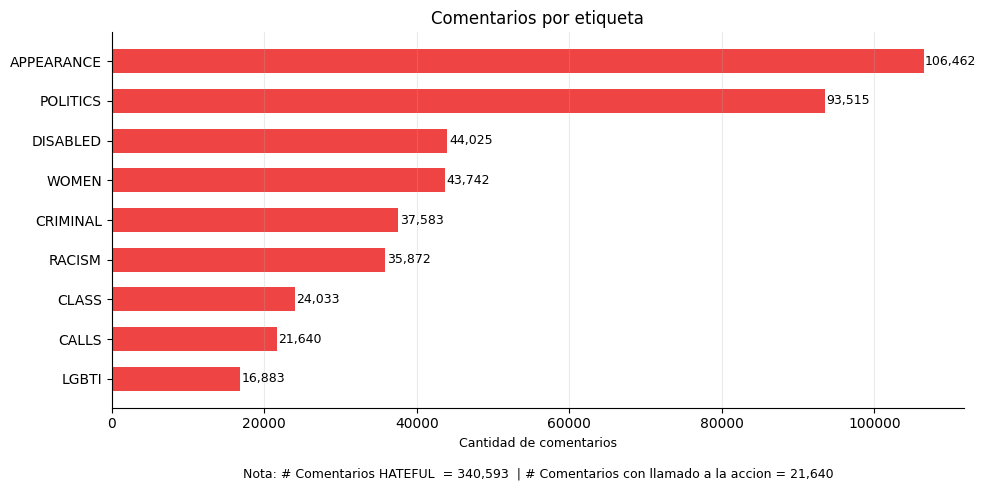

In [17]:
#Grafico de comentarios por etiqueta (excluye HATEFUL) 
sorted_c = comentarios_por_etiqueta[~comentarios_por_etiqueta['etiqueta'].isin(['HATEFUL'])].sort_values('comentarios', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sorted_c['etiqueta'], sorted_c['comentarios'], color='#ef4444', height=0.6)
for i, (_, row) in enumerate(sorted_c.iterrows()):
    ax.text(row['comentarios'] + 200, i, f"{int(row['comentarios']):,}", va='center', fontsize=9)

# Valores de HATEFUL y CALLS aparte
hateful_n = comentarios_por_etiqueta.loc[comentarios_por_etiqueta['etiqueta'] == 'HATEFUL', 'comentarios'].values[0]
calls_n   = comentarios_por_etiqueta.loc[comentarios_por_etiqueta['etiqueta'] == 'CALLS',   'comentarios'].values[0]
ax.set_title('Comentarios por etiqueta', fontsize=12)
ax.set_xlabel(f'Cantidad de comentarios\n\nNota: # Comentarios HATEFUL  = {int(hateful_n):,}  | # Comentarios con llamado a la accion = {int(calls_n):,}', fontsize=9)
ax.grid(axis='x', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

### 3.2. ¿Cuántas noticias por etiqueta? 



In [18]:
# Noticias por etiqueta (al menos un comentario con etiqueta = 1 en esa categoria)
noticias_por_etiqueta = (
    tw_arg.groupby('tweet_id_noticia')[etiquetas]
    .max() 
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
noticias_por_etiqueta.columns = ['etiqueta', 'noticias']

print("\nNoticias por etiqueta:")
print(noticias_por_etiqueta.to_string(index=False))


Noticias por etiqueta:
  etiqueta  noticias
   HATEFUL     81515
  POLITICS     36812
APPEARANCE     30719
    RACISM     17692
     WOMEN     16983
  DISABLED     16777
     CLASS     10815
     CALLS     10276
  CRIMINAL      8322
     LGBTI      7954


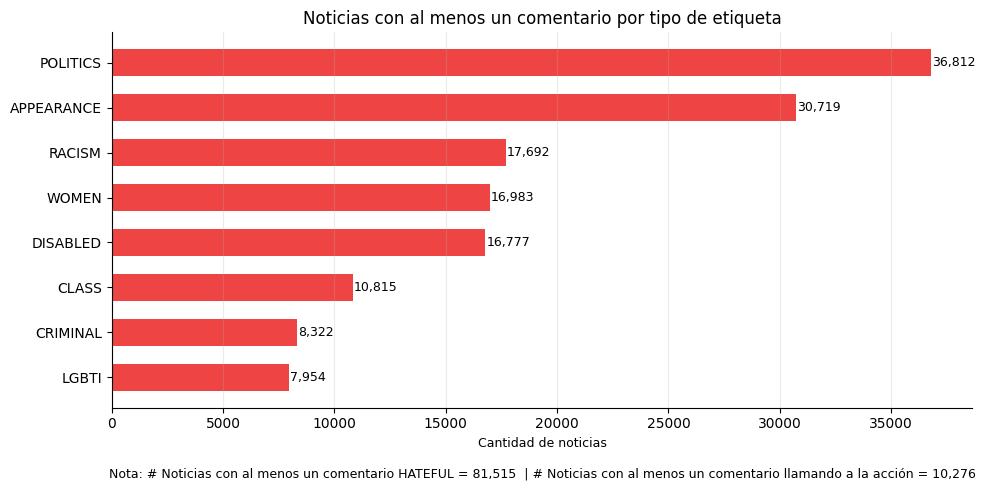

In [19]:
# Grafico de noticias por etiqueta (excluye HATEFUL y CALLS)
sorted_n = noticias_por_etiqueta[~noticias_por_etiqueta['etiqueta'].isin(etiquetas_adicionales)].sort_values('noticias', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sorted_n['etiqueta'], sorted_n['noticias'], color='#ef4444', height=0.6)
for i, (_, row) in enumerate(sorted_n.iterrows()):
    ax.text(row['noticias'] + 50, i, f"{int(row['noticias']):,}", va='center', fontsize=9)

hateful_n_not = noticias_por_etiqueta.loc[noticias_por_etiqueta['etiqueta'] == 'HATEFUL', 'noticias'].values[0]
calls_n_not   = noticias_por_etiqueta.loc[noticias_por_etiqueta['etiqueta'] == 'CALLS',   'noticias'].values[0]
ax.set_title('Noticias con al menos un comentario por tipo de etiqueta', fontsize=12)
ax.set_xlabel(f'Cantidad de noticias\n\nNota: # Noticias con al menos un comentario HATEFUL = {int(hateful_n_not):,}  | # Noticias con al menos un comentario llamando a la acción = {int(calls_n_not):,}', fontsize=9)
ax.grid(axis='x', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

###  3.3.Noticias por etiqueta dominante 

Para cada noticia, solo se la va a contar en la etiqueta para la cual recibio mas comentarios

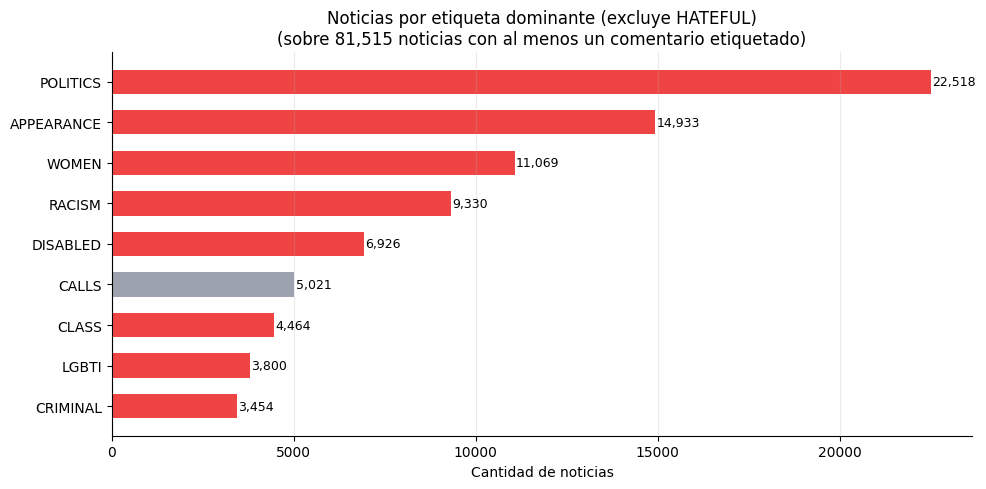

In [20]:
# Grafico de etiqueta dominante excluyendo HATEFUL
etiquetas_dominante = [e for e in etiquetas if e not in ('HATEFUL',)]

conteos_por_noticia = tw_arg.groupby('tweet_id_noticia')[etiquetas_dominante].sum()
conteos_por_noticia = conteos_por_noticia[conteos_por_noticia.sum(axis=1) > 0]
etiqueta_dominante = conteos_por_noticia.idxmax(axis=1)

dominante_counts = (etiqueta_dominante.value_counts()
                    .reset_index()
                    .rename(columns={'index': 'etiqueta', 'count': 'noticias'})
                    .sort_values('noticias', ascending=True))

bar_colors_dom = [color_etiqueta(e) for e in dominante_counts['etiqueta']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dominante_counts['etiqueta'], dominante_counts['noticias'], color=bar_colors_dom, height=0.6)
for i, (_, row) in enumerate(dominante_counts.iterrows()):
    ax.text(row['noticias'] + 30, i, f"{int(row['noticias']):,}", va='center', fontsize=9)

total_etiquetadas = len(etiqueta_dominante)
ax.set_title(f'Noticias por etiqueta dominante (excluye HATEFUL)\n(sobre {total_etiquetadas:,} noticias con al menos un comentario etiquetado)', fontsize=12)
ax.set_xlabel('Cantidad de noticias')
ax.grid(axis='x', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

### 3.4 Noticia con mas comentarios racistas en general

In [21]:
racism_por_noticia = (tw_arg[tw_arg['RACISM'] == 1]
                      .groupby('tweet_id_noticia')
                      .agg(n_racism=('RACISM', 'sum'),
                           medio=('medio', 'first'),
                           date=('date_tweet', 'min'))
                      .reset_index()
                      .sort_values('n_racism', ascending=False))

top_noticia = racism_por_noticia.iloc[0]

# Obtener título desde tw_arg (ya disponible en el dataset)
info_noticia = tw_arg[tw_arg['tweet_id_noticia'] == top_noticia['tweet_id_noticia']].iloc[0]

print(f"Noticia con más comentarios racistas:")
print(f"  tweet_id_noticia : {top_noticia['tweet_id_noticia']}")
print(f"  Medio            : {top_noticia['medio']}")
print(f"  Fecha            : {top_noticia['date'].date()}")
print(f"  Comentarios RACISM: {int(top_noticia['n_racism'])}")
print(f"  Título           : {info_noticia['title']}")

print(f"\nMuestra de comentarios racistas de esa noticia:")
comentarios_top = tw_arg[(tw_arg['tweet_id_noticia'] == top_noticia['tweet_id_noticia']) &
                          (tw_arg['RACISM'] == 1)]['text'].sample(5, random_state=42)
for c in comentarios_top:
    print(f"  - {c}")

Noticia con más comentarios racistas:
  tweet_id_noticia : 1242108524882202625
  Medio            : infobae
  Fecha            : 2020-03-23
  Comentarios RACISM: 312
  Título           : Tres extranjeros incumplían la cuarentena total y agredieron a los policías que quisieron identificarlos

Muestra de comentarios racistas de esa noticia:
  - @infobae @nandusll1946 Antes de ser deportados estos tres soretes hijos de puta, deben estar presos , pagarse su comida y los gastos y etc
  - @infobae Esa es la mierda social que dejamos entrar a nuestro país
  - @infobae Fuera del país fuera fuera
  - @infobae Rompanle las rodillas , las dos bien molidas . Así aprenden si no damos un ejemplo,  nadie respeta.
  - @infobae y asi hay muchos peruanos hablando de nosotros los venezolanos? miren lo que hacen sus compatriota en el exterior.. pura mierda


### 3.5. Noticias con mas comentarios racistas por medio

In [22]:
# Noticia con más comentarios RACISM por medio
top_racism_por_medio = (
    tw_arg[tw_arg['RACISM'] == 1]
    .groupby(['medio', 'tweet_id_noticia'])
    .agg(
        comentarios_racism=('id', 'count'),
        title=('title', 'first'),
        resumen=('resumen', 'first'),
        fecha=('date_tweet', 'min')
    )
    .reset_index()
    .sort_values('comentarios_racism', ascending=False)
    .groupby('medio')
    .first()
    .reset_index()
    .sort_values('comentarios_racism', ascending=False)
)

top_racism_por_medio['link'] = top_racism_por_medio['resumen'].str.split().str[-1]

for _, row in top_racism_por_medio.iterrows():
    print(f"{'─'*80}")
    print(f"  Medio             : {row['medio']}")
    print(f"  Comentarios RACISM: {int(row['comentarios_racism']):,}")
    print(f"  Fecha             : {row['fecha'].date()}")
    print(f"  Titulo            : {row['title']}")
    print(f"  Link              : {row['link']}")
    muestra = (tw_arg[(tw_arg['tweet_id_noticia'] == row['tweet_id_noticia']) &
                      (tw_arg['RACISM'] == 1)]['text']
               .sample(min(3, row['comentarios_racism']), random_state=42))
    print(f"  Muestra de comentarios:")
    for c in muestra:
        print(f"    · {c}")
print(f"{'─'*80}")

────────────────────────────────────────────────────────────────────────────────
  Medio             : infobae
  Comentarios RACISM: 312
  Fecha             : 2020-03-23
  Titulo            : Tres extranjeros incumplían la cuarentena total y agredieron a los policías que quisieron identificarlos
  Link              : https://t.co/r40lhweP5P
  Muestra de comentarios:
    · @infobae @nandusll1946 Antes de ser deportados estos tres soretes hijos de puta, deben estar presos , pagarse su comida y los gastos y etc
    · @infobae Esa es la mierda social que dejamos entrar a nuestro país
    · @infobae Fuera del país fuera fuera
────────────────────────────────────────────────────────────────────────────────
  Medio             : clarincom
  Comentarios RACISM: 178
  Fecha             : 2020-09-18
  Titulo            : Brucelosis en China: se escapó una bacteria de un laboratorio y ya hay más de 3.000 enfermos
  Link              : https://t.co/Wt2rYhH1z1
  Muestra de comentarios:
    · @clari

## 4. Llamados a la acción por etiqueta

La columna CALLS indica que el comentario contiene un llamado explícito a hacer algo (denunciar, expulsar, agredir, etc.). Se analiza qué proporción de los comentarios de cada categoría de odio incluyen además un llamado a la acción, y cuáles son los subtipos más frecuentes dentro de los comentarios con `CALLS = 1`.

### 4.1. Llamados por etiqueta

In [23]:
calls_df = tw_arg[tw_arg['CALLS'] == 1] #Separamos los comentarios con llamadas a la accion

# Excluimos CALLS para no cruzarla consigo misma
etiquetas_odio = [e for e in etiquetas if e != 'CALLS']

resultado = []
for etiqueta in etiquetas_odio:
    total = tw_arg[etiqueta].sum() 
    calls = calls_df[etiqueta].sum() 
    porcentaje = calls / total * 100 if total > 0 else 0 # porcentaje de com. con llamados a la accion sobre el total de cada etiqueta
    resultado.append({'etiqueta': etiqueta, 'total': total, 'llamados a la accion': calls, '% llamados': round(porcentaje, 1)})

calls_por_etiqueta = pd.DataFrame(resultado).sort_values('llamados a la accion', ascending=False).reset_index(drop=True)
calls_por_etiqueta

,etiqueta,total,llamados a la accion,% llamados
0,HATEFUL,340593,21640,6.4
1,CRIMINAL,37583,11865,31.6
2,RACISM,35872,5541,15.4
3,POLITICS,93515,4175,4.5
4,CLASS,24033,2509,10.4
5,APPEARANCE,106462,650,0.6
6,WOMEN,43742,445,1.0
7,LGBTI,16883,178,1.1
8,DISABLED,44025,177,0.4


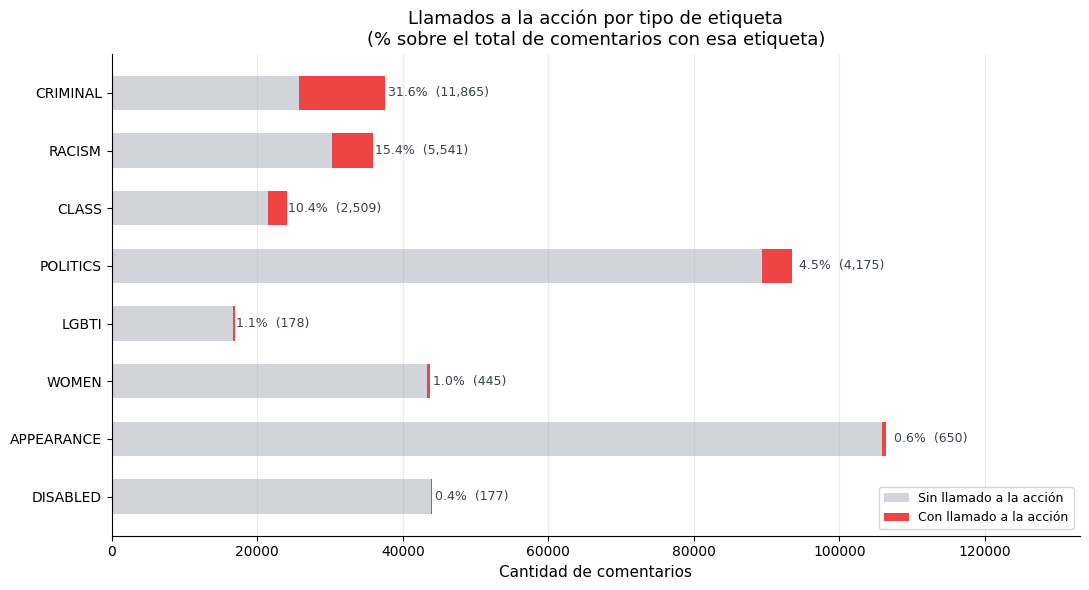

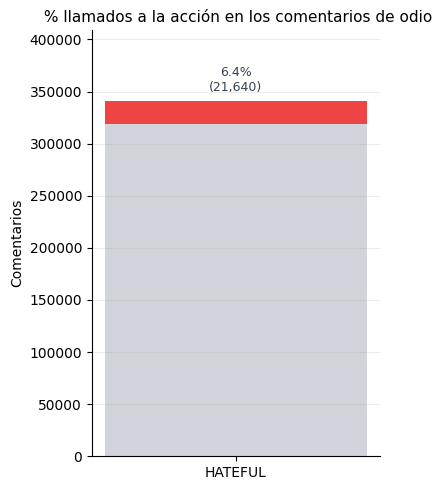

In [24]:
# Grafico de llamados a la acción por etiqueta (sin HATEFUL)
sorted_pct = (calls_por_etiqueta[calls_por_etiqueta['etiqueta'] != 'HATEFUL']
              .sort_values('% llamados', ascending=True)
              .reset_index(drop=True))

hateful_row = calls_por_etiqueta[calls_por_etiqueta['etiqueta'] == 'HATEFUL'].iloc[0]

sin_calls = sorted_pct['total'] - sorted_pct['llamados a la accion']
con_calls = sorted_pct['llamados a la accion']

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(sorted_pct['etiqueta'], sin_calls, color='#d1d5db', label='Sin llamado a la acción', height=0.6)
ax.barh(sorted_pct['etiqueta'], con_calls, left=sin_calls, color='#ef4444', label='Con llamado a la acción', height=0.6)
for i, (_, row) in enumerate(sorted_pct.iterrows()):
    ax.text(row['total'] + row['total'] * 0.01, i,
            f"{row['% llamados']}%  ({int(row['llamados a la accion']):,})",
            va='center', ha='left', fontsize=9, color='#374151')
ax.set_xlim(0, sorted_pct['total'].max() * 1.25)
ax.set_xlabel('Cantidad de comentarios', fontsize=11)
ax.set_title('Llamados a la acción por tipo de etiqueta\n(% sobre el total de comentarios con esa etiqueta)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Gráfico HATEFUL aparte
sin_h = hateful_row['total'] - hateful_row['llamados a la accion']
con_h = hateful_row['llamados a la accion']

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(['HATEFUL'], [sin_h], color='#d1d5db', width=0.4)
ax.bar(['HATEFUL'], [con_h], bottom=[sin_h], color='#ef4444', width=0.4)
ax.text(0, hateful_row['total'] * 1.02,
        f"{hateful_row['% llamados']}%\n({int(con_h):,})",
        ha='center', va='bottom', fontsize=9, color='#374151')
ax.set_ylim(0, hateful_row['total'] * 1.2)
ax.set_ylabel('Comentarios', fontsize=10)
ax.set_title(' % llamados a la acción en los comentarios de odio', fontsize=11)
ax.grid(axis='y', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

### 4.2. Etiquetas por llamados

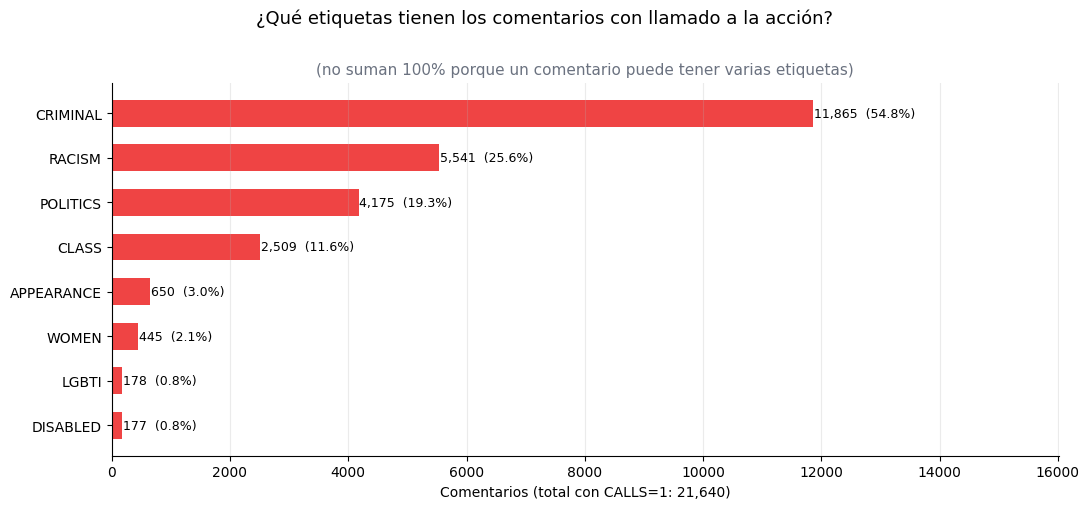

De los 21,640 comentarios de odio con llamado a la acción, 5,541 (25.6%) son racistas.


In [25]:
# Distribución de subtipos de odio dentro de los comentarios con llamado a la acción
calls_df = tw_arg[tw_arg['CALLS'] == 1]
subtipos = [e for e in etiquetas if e not in ['CALLS', 'HATEFUL']]
conteos = calls_df[subtipos].sum().sort_values(ascending=True)
total_calls = len(calls_df)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(conteos.index, conteos.values, color='#ef4444', height=0.6)
for i, (subtipo, val) in enumerate(conteos.items()):
    pct = val / total_calls * 100
    ax.text(val + 10, i, f"{int(val):,}  ({pct:.1f}%)", va='center', fontsize=9)

ax.set_xlim(0, conteos.max() * 1.35)
ax.set_title('(no suman 100% porque un comentario puede tener varias etiquetas)', fontsize=11, color='#6b7280')
fig.suptitle('¿Qué etiquetas tienen los comentarios con llamado a la acción?', fontsize=13, y=1.01)
ax.set_xlabel(f'Comentarios (total con CALLS=1: {total_calls:,})')
ax.grid(axis='x', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Stat: qué proporción de los comentarios de odio+llamado son además racistas
hate_calls = tw_arg[(tw_arg['HATEFUL'] == 1) & (tw_arg['CALLS'] == 1)]
hate_calls_racist = hate_calls[hate_calls['RACISM'] == 1]
pct_racist = len(hate_calls_racist) / len(hate_calls) * 100
print(f"De los {len(hate_calls):,} comentarios de odio con llamado a la acción, "
      f"{len(hate_calls_racist):,} ({pct_racist:.1f}%) son racistas.")

### 4.3. Comentarios con solo CALLS (sin ninguna otra etiqueta de categoría)

Comentarios donde `CALLS = 1` pero todas las demás etiquetas de categoría son 0. 

In [26]:
etiquetas_categoria = [e for e in etiquetas if e not in ('HATEFUL', 'CALLS')]

solo_calls = tw_arg[(tw_arg['CALLS'] == 1) & (tw_arg[etiquetas_categoria].sum(axis=1) == 0)]

print(f"Comentarios con solo CALLS (sin otra etiqueta asignada): {len(solo_calls):,} ({len(solo_calls)/len(tw_arg)*100:.2f}% del total)")

# Distribucion por medio
print("\nDistribucion por medio:")
print(solo_calls.groupby('medio').size().sort_values(ascending=False).to_string())

# Muestra de comentarios
print("\nMuestra de comentarios con solo CALLS:")
for c in solo_calls['text'].sample(10, random_state=42):
    print(f"  · {c}")

Comentarios con solo CALLS (sin otra etiqueta asignada): 1,568 (0.03% del total)

Distribucion por medio:
medio
infobae            493
clarincom          421
LANACION           393
cronica             80
pagina12            62
laderechadiario     45
laderechamedios     35
perfilcom           27
izquierdadiario     12

Muestra de comentarios con solo CALLS:
  · @clarincom Clarin hdp.....hay que incendiarlos a uds
  · @LANACION Balas.
  · @clarincom Yo diría fusilamiento!
  · @clarincom Mueranse
  · @clarincom Grillete , pico y pala y que las construyan ellos !
  · @LANACION Habia fusilamientos también,no se andaban con vueltas
  · @infobae Dos patadas en el toor a cada uno y solucionado la'sunto!
  · @clarincom Hay q empezar hacer justicia y un tiro en la frente a los delincuentes y listo
  · @laderechadiario Que pais de mierda. Tendríamos que estar quemado la casa de ese hdmp.
  · @LANACION Lo que se encuantra amenzada es su libertad... POR DELINCUENTE... Hay que colgarlo en la Pza de 

### 4.4. Noticia con más comentarios con llamados a la acción por medio

In [27]:
# Noticia con más comentarios CALLS por medio
top_calls_por_medio = (
    tw_arg[tw_arg['CALLS'] == 1]
    .groupby(['medio', 'tweet_id_noticia'])
    .agg(
        comentarios_calls=('id', 'count'),
        title=('title', 'first'),
        resumen=('resumen', 'first'),
        fecha=('date_tweet', 'min')
    )
    .reset_index()
    .sort_values('comentarios_calls', ascending=False)
    .groupby('medio')
    .first()
    .reset_index()
    .sort_values('comentarios_calls', ascending=False)
)

top_calls_por_medio['link'] = top_calls_por_medio['resumen'].str.split().str[-1]

for _, row in top_calls_por_medio.iterrows():
    print(f"{'─'*80}")
    print(f"  Medio           : {row['medio']}")
    print(f"  Comentarios CALLS: {int(row['comentarios_calls']):,}")
    print(f"  Fecha           : {row['fecha'].date()}")
    print(f"  Titulo          : {row['title']}")
    print(f"  Link            : {row['link']}")
    muestra = (tw_arg[(tw_arg['tweet_id_noticia'] == row['tweet_id_noticia']) &
                      (tw_arg['CALLS'] == 1)]['text']
               .sample(min(3, row['comentarios_calls']), random_state=42))
    print(f"  Muestra de comentarios:")
    for c in muestra:
        print(f"    · {c}")
print(f"{'─'*80}")

────────────────────────────────────────────────────────────────────────────────
  Medio           : infobae
  Comentarios CALLS: 251
  Fecha           : 2020-03-23
  Titulo          : Tres extranjeros incumplían la cuarentena total y agredieron a los policías que quisieron identificarlos
  Link            : https://t.co/r40lhweP5P
  Muestra de comentarios:
    · @infobae Mejor me llamo a silencio
    · @infobae Yo diría cuarentena para ellos y sus barrigas que tengan calabozos aparte
    · @infobae @MarusaEstebanok Derechito a su pais
────────────────────────────────────────────────────────────────────────────────
  Medio           : clarincom
  Comentarios CALLS: 131
  Fecha           : 2020-08-05
  Titulo          : Sorprendió a una abuela en el patio de su casa, la violó y le robó hasta la dentadura postiza
  Link            : https://t.co/sjtJVzRVxi
  Muestra de comentarios:
    · @clarincom Se cura con plomo a PRESIÓN!
    · @clarincom Tortura y muerte la única solución.
Estas la

### 4.5 Búsqueda de coincidencias entre los top N de noticias con mas calls y con mas comentarios racistas

In [28]:
N = 20

top_calls_global = (
    tw_arg[tw_arg['CALLS'] == 1]
    .groupby('tweet_id_noticia')
    .agg(comentarios_calls=('id', 'count'), title=('title', 'first'),
         resumen=('resumen', 'first'), medio=('medio', 'first'))
    .reset_index()
    .nlargest(N, 'comentarios_calls')
)
top_calls_global['link'] = top_calls_global['resumen'].str.split().str[-1]

top_racism_global = (
    tw_arg[tw_arg['RACISM'] == 1]
    .groupby('tweet_id_noticia')
    .agg(comentarios_racism=('id', 'count'), title=('title', 'first'),
         medio=('medio', 'first'))
    .reset_index()
    .nlargest(N, 'comentarios_racism')
)

ids_calls  = set(top_calls_global['tweet_id_noticia'])
ids_racism = set(top_racism_global['tweet_id_noticia'])
coincidencias = ids_calls & ids_racism

print(f"Coincidencias entre top {N} CALLS y top {N} RACISM: {len(coincidencias)}\n")

if coincidencias:
    for tid in coincidencias:
        fc = top_calls_global[top_calls_global['tweet_id_noticia'] == tid].iloc[0]
        fr = top_racism_global[top_racism_global['tweet_id_noticia'] == tid].iloc[0]
        print(f"  Medio             : {fc['medio']}")
        print(f"  Titulo            : {fc['title']}")
        print(f"  Link              : {fc['link']}")
        print(f"  Comentarios CALLS : {int(fc['comentarios_calls']):,}")
        print(f"  Comentarios RACISM: {int(fr['comentarios_racism']):,}")
        print()
else:
    print(f"Ninguna noticia del top {N} de CALLS aparece en el top {N} de RACISM.")

Coincidencias entre top 20 CALLS y top 20 RACISM: 6

  Medio             : infobae
  Titulo            : Un diputado chileno propuso trasladar a enfermos de coronavirus a la Argentina
  Link              : https://t.co/X7REunq8Mt
  Comentarios CALLS : 55
  Comentarios RACISM: 158

  Medio             : infobae
  Titulo            : Tres extranjeros incumplían la cuarentena total y agredieron a los policías que quisieron identificarlos
  Link              : https://t.co/r40lhweP5P
  Comentarios CALLS : 251
  Comentarios RACISM: 312

  Medio             : clarincom
  Titulo            : Brucelosis en China: se escapó una bacteria de un laboratorio y ya hay más de 3.000 enfermos
  Link              : https://t.co/Wt2rYhH1z1
  Comentarios CALLS : 60
  Comentarios RACISM: 178

  Medio             : izquierdadiario
  Titulo            : El Ejército invadió tierras pertenecientes a una comunidad mapuche en Bariloche
  Link              : https://t.co/U1ew7a0TPn
  Comentarios CALLS : 52
  Come

## 5. Ejemplos de comentarios racistas

Muestra de comentarios clasificados con `RACISM = 1`, tanto sin llamado a la acción como con `CALLS = 1`.

In [29]:
#Ejemplos de comentarios racistas 
racist_tweets = tw_arg[tw_arg['RACISM'] == 1]['text'].sample(5, random_state=42)
print("Ejemplos de tweets racistas:")
for tweet in racist_tweets:
    print(tweet)

#Ejemplos de comentarios racistas con llamadas a la acción
racist_calls = tw_arg[(tw_arg['RACISM'] == 1) & (tw_arg['CALLS'] == 1)]
print("\nEjemplos de tweets racistas con llamadas a la acción:") 
for tweet in racist_calls['text'].sample(5, random_state=42):
    print(tweet)

Ejemplos de tweets racistas:
@laderechamedios @AgusHH26 que putos que son los canadienses hermano
@LANACION Los militares no sirven para nada. 
Hartos estarán los ciudadanos de esta mierda que ni siquiera las Naciones Unidas pueden detener. 
Mis alejados pero sinceros sentimientos ante esta mounstrosidad.
@infobae @rousbral Sacame estos gronchos de mi vista .vagos del orto .se merecen como viven !
@clarincom @Liliana97418128 pero estos no le rezan a un palo o a una piedra? ahora quieren carta del jefe de la banda? saquenlos a los tiros.
@infobae @fernandocarnota Al fin se fue el pata sucia!!!!

Ejemplos de tweets racistas con llamadas a la acción:
@pagina12 Que tiren una bomba nuclear que mate a los kukas, las cucarachas sobreviven a la explosión
@LANACION @Blansh19 A la qué hay que deportar en primer lugar es a la Sagasti 🤢
@infobae No hay que venderles nada a los chinos! Que paguen el daño!
@laderechadiario Lo mejor que le puede pasar al mundo es desaparezcan.
@cronica Es un buen mom

## 6. Co-ocurrencia de etiquetas

Se analiza la relación entre etiquetas de odio, incluyendo CALLS. Se muestran dos matrices:

- **Co-ocurrencia absoluta**
- **Correlación**

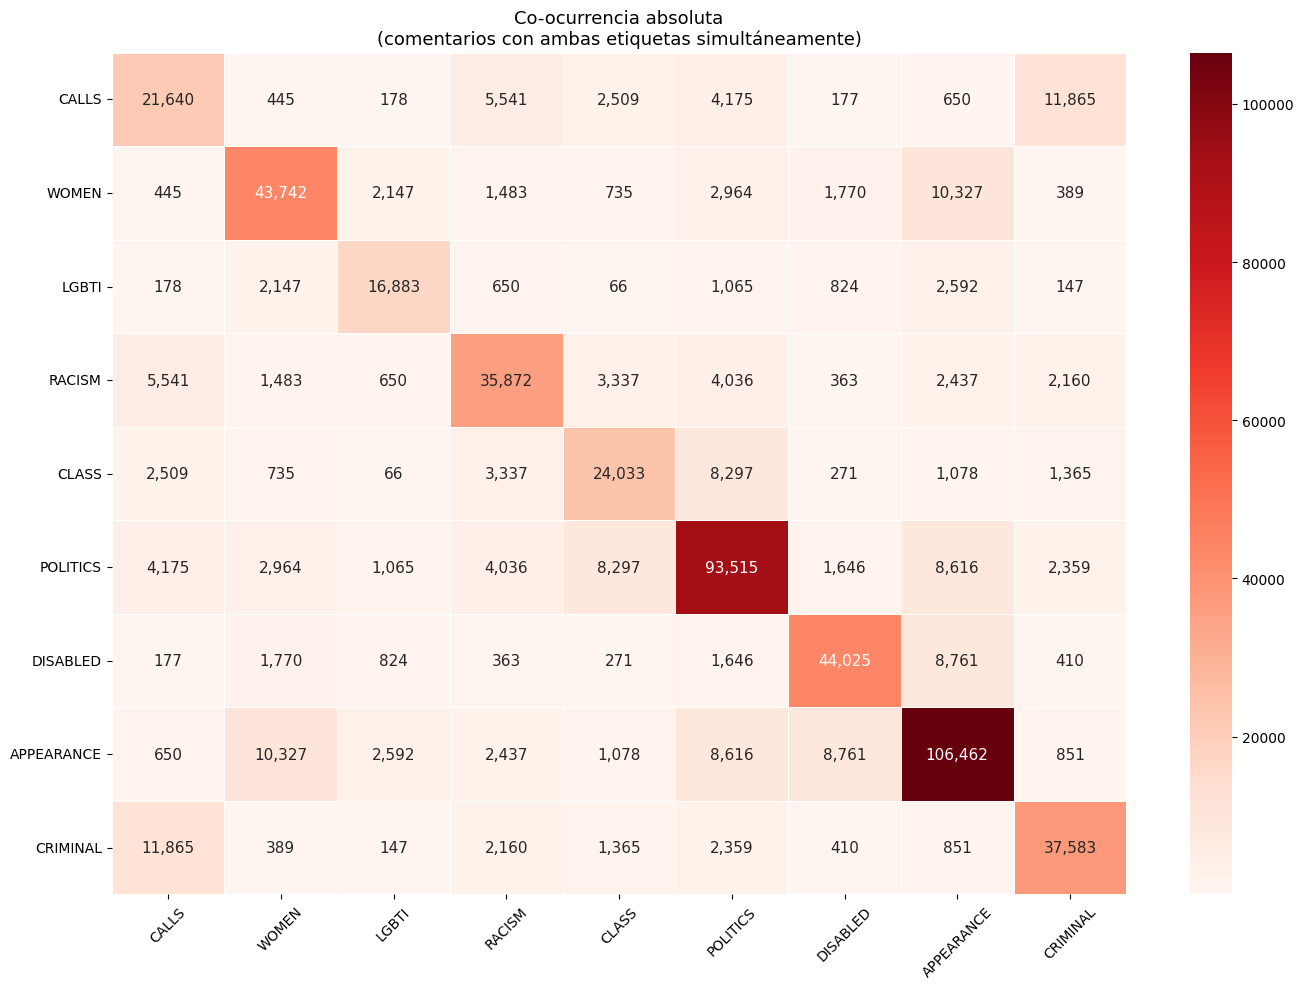

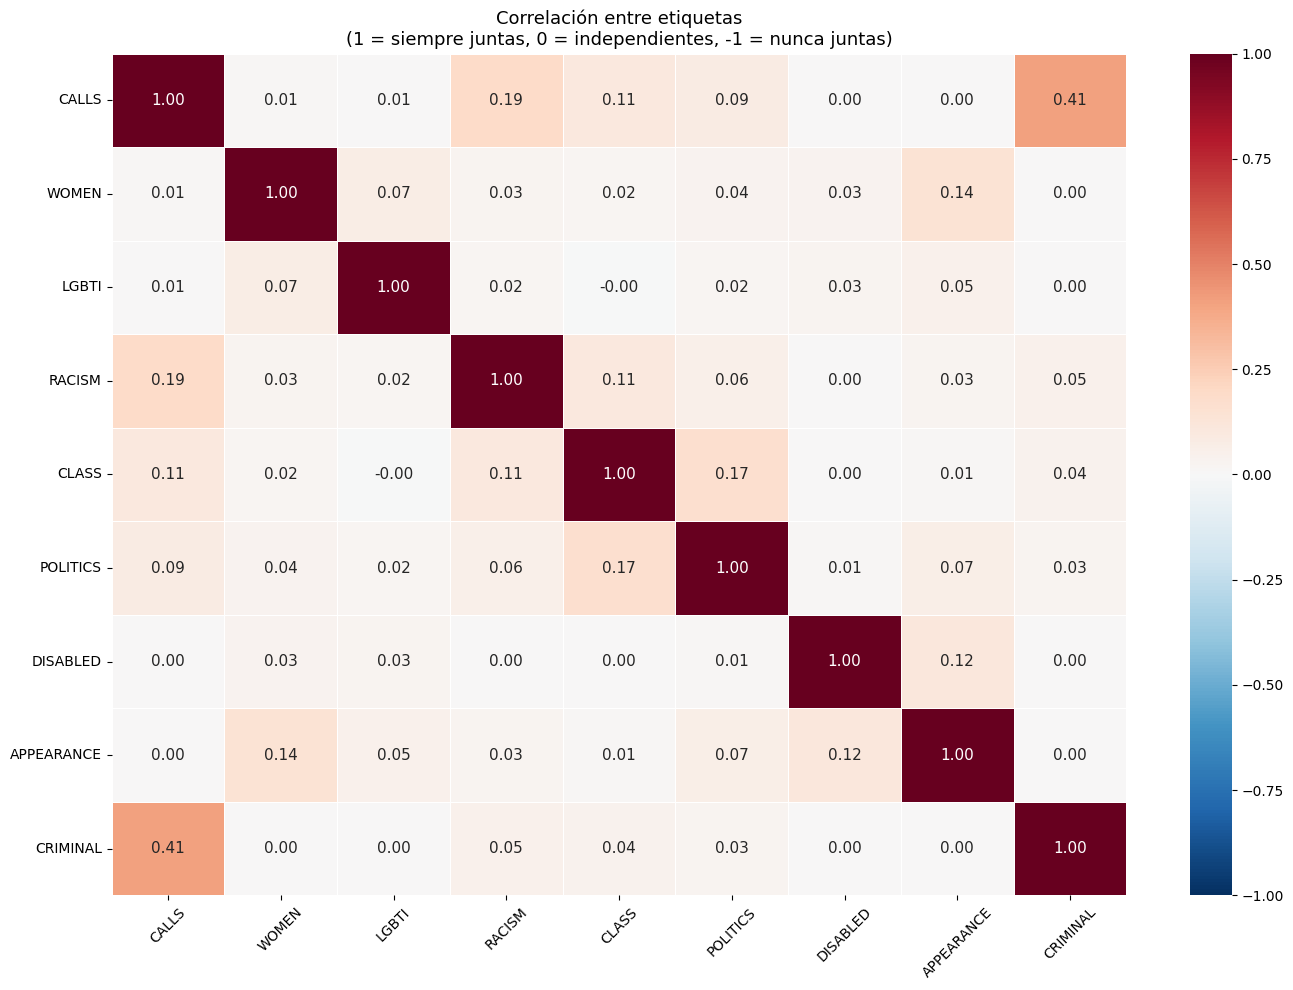

In [30]:
# Co-ocurrencia de etiquetas de odio + CALLS (excluye solo HATEFUL)
etiquetas_cooc = [e for e in etiquetas if e != 'HATEFUL']
df_cooc = tw_arg[etiquetas_cooc]

cooc = df_cooc.T.dot(df_cooc)
phi  = df_cooc.corr()

# --- Co-ocurrencia absoluta ---
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cooc, ax=ax, fmt=',d', annot=True, cmap='Reds',
            linewidths=0.5, annot_kws={'size': 11})
ax.set_title('Co-ocurrencia absoluta\n(comentarios con ambas etiquetas simultáneamente)', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# --- Correlación  ---
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(phi, ax=ax, fmt='.2f', annot=True, cmap='RdBu_r',
            linewidths=0.5, annot_kws={'size': 11}, vmin=-1, vmax=1, center=0)
ax.set_title('Correlación entre etiquetas\n(1 = siempre juntas, 0 = independientes, -1 = nunca juntas)', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 7. Análisis Temporal

### 7.1. Promedio de comentarios por noticia por medio y mes

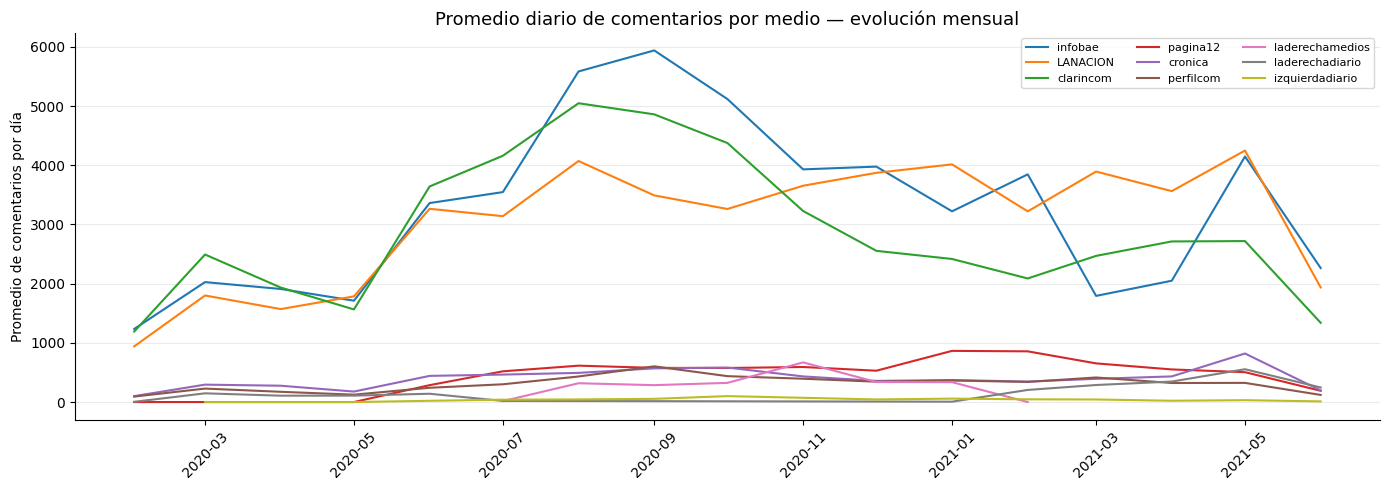

In [31]:
# Promedio diario de comentarios por medio por mes
tw_arg['mes'] = tw_arg['date_tweet'].dt.to_period('M')

comentarios_mes = tw_arg.groupby(['medio', 'mes']).size().reset_index(name='total')
comentarios_mes['dias'] = comentarios_mes['mes'].dt.days_in_month
comentarios_mes['promedio_diario'] = comentarios_mes['total'] / comentarios_mes['dias']
comentarios_mes['fecha'] = comentarios_mes['mes'].dt.to_timestamp()

orden_medios_vol = (
    comentarios_mes.groupby('medio')['total'].sum()
    .sort_values(ascending=False).index.tolist()
)
palette_medios = dict(zip(orden_medios_vol, sns.color_palette('tab10', n_colors=len(orden_medios_vol))))

fig, ax = plt.subplots(figsize=(14, 5))
for medio in orden_medios_vol:
    d = comentarios_mes[comentarios_mes['medio'] == medio]
    ax.plot(d['fecha'], d['promedio_diario'], label=medio, color=palette_medios[medio], linewidth=1.5)

ax.set_title('Promedio diario de comentarios por medio — evolución mensual', fontsize=13)
ax.set_ylabel('Promedio de comentarios por día')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(axis='y', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

In [32]:
# Promedio mensual de comentarios por medio
tabla_promedio_mensual = (
    comentarios_mes.groupby('medio')['total']
    .mean()
    .round(0)
    .astype(int)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'total': 'promedio_comentarios_por_mes'})
)
tabla_promedio_mensual

,medio,promedio_comentarios_por_mes
0,infobae,99519
1,LANACION,92606
2,clarincom,87413
3,pagina12,13057
4,cronica,12093
5,perfilcom,9404
6,laderechamedios,8743
7,laderechadiario,5492
8,izquierdadiario,1124


### 7.2. Promedio de comentarios por noticia por trimestre

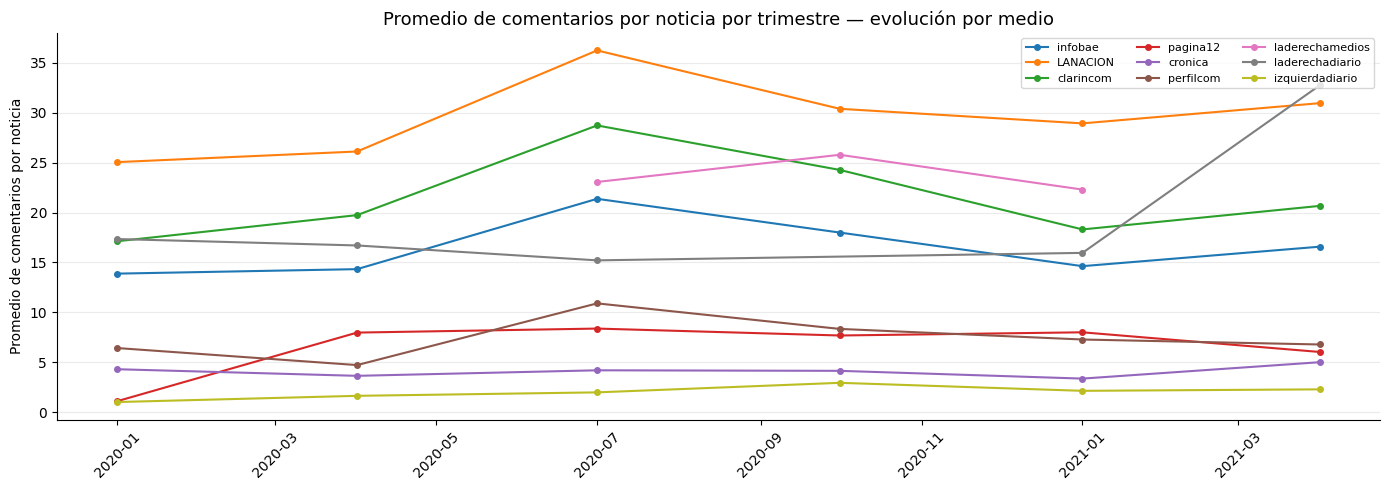

In [33]:
# Promedio de comentarios por noticia por trimestre y medio
tw_arg['trimestre'] = tw_arg['date_tweet'].dt.to_period('Q')

comentarios_trim = tw_arg.groupby(['medio', 'trimestre']).size().reset_index(name='total')
noticias_trim = tw_arg.groupby(['medio', 'trimestre'])['tweet_id_noticia'].nunique().reset_index(name='noticias')

avg_trim = comentarios_trim.merge(noticias_trim, on=['medio', 'trimestre'])
avg_trim['avg'] = avg_trim['total'] / avg_trim['noticias']
avg_trim['fecha'] = avg_trim['trimestre'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for medio in orden_medios_vol:
    d = avg_trim[avg_trim['medio'] == medio]
    ax.plot(d['fecha'], d['avg'], label=medio, color=palette_medios[medio],
            linewidth=1.5, marker='o', markersize=4)

ax.set_title('Promedio de comentarios por noticia por trimestre — evolución por medio', fontsize=13)
ax.set_ylabel('Promedio de comentarios por noticia')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(axis='y', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

### 7.3. Serie temporal de comentarios de odio por dia

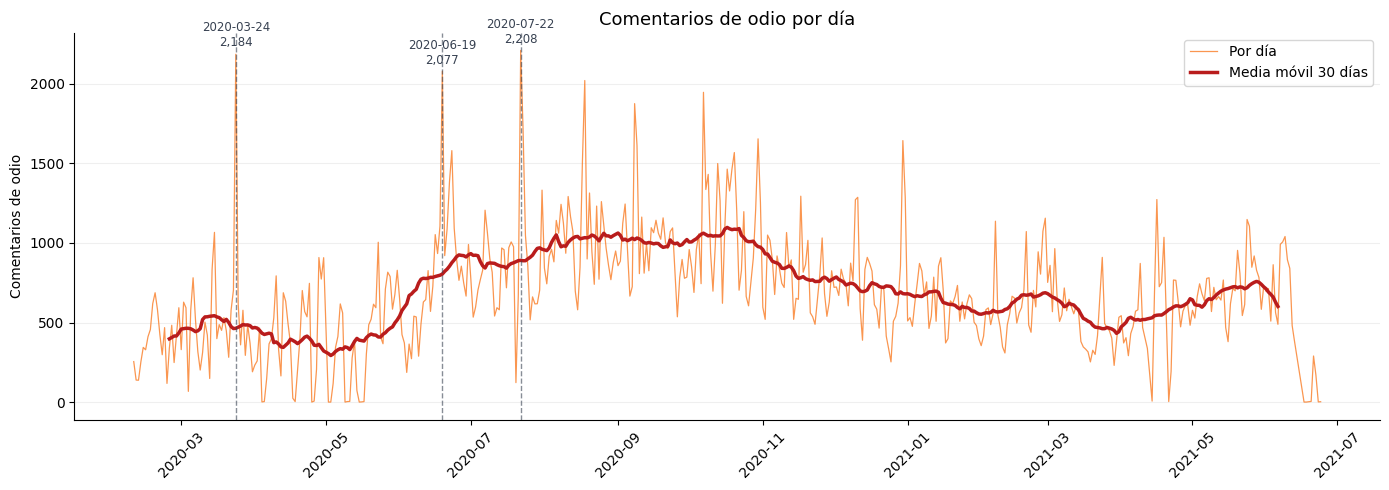

In [34]:
#Evolución temporal de los comentarios de odio por día
tw_arg['date_only'] = tw_arg['date_tweet'].dt.date
hate_daily_counts = tw_arg[tw_arg['HATEFUL'] == 1].groupby('date_only').size().reset_index(name='hate_tweet_count')
hate_daily_counts['rolling_30'] = hate_daily_counts['hate_tweet_count'].rolling(30, center=True).mean()
hate_daily_counts['date_dt'] = pd.to_datetime(hate_daily_counts['date_only'])

top_picos = hate_daily_counts.nlargest(3, 'hate_tweet_count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hate_daily_counts['date_dt'], hate_daily_counts['hate_tweet_count'],
        color='#f97316', linewidth=0.9, alpha=0.75, label='Por día')
ax.plot(hate_daily_counts['date_dt'], hate_daily_counts['rolling_30'],
        color='#b91c1c', linewidth=2.5, label='Media móvil 30 días')

for _, row in top_picos.iterrows():
    ax.axvline(row['date_dt'], color='#374151', linewidth=1, linestyle='--', alpha=0.6)
    ax.text(row['date_dt'], row['hate_tweet_count'] + 30,
            f"{row['date_only']}\n{int(row['hate_tweet_count']):,}",
            ha='center', va='bottom', fontsize=8.5, color='#374151')

ax.set_title('Comentarios de odio por día', fontsize=13)
ax.set_ylabel('Comentarios de odio')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

### 7.4. Picos secundarios de odio 

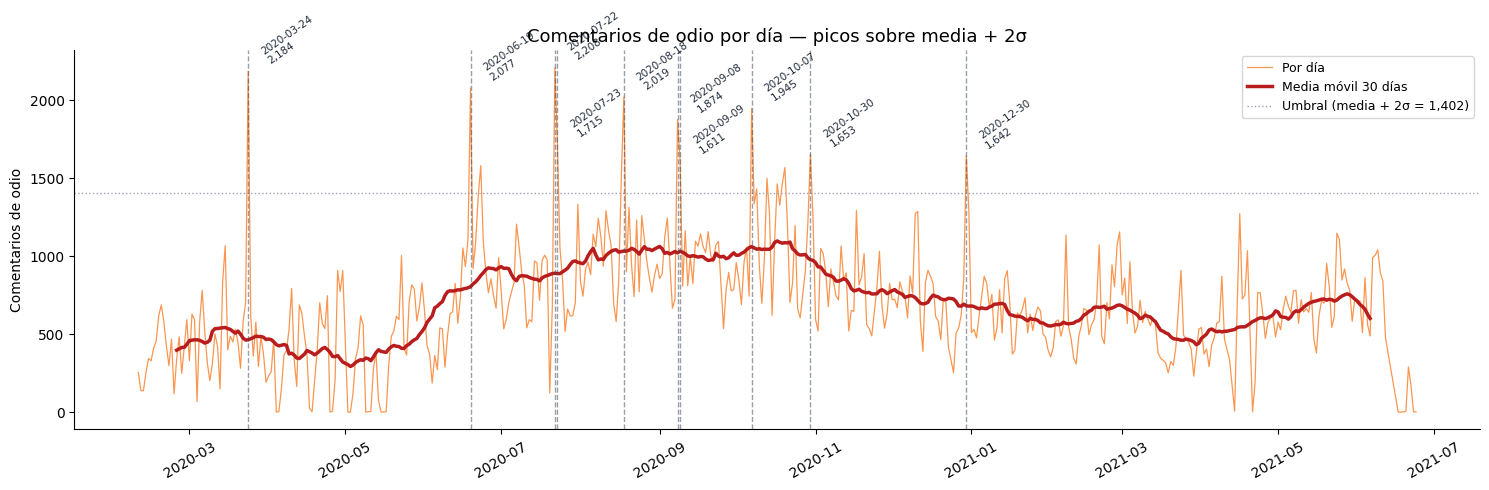

Días sobre el umbral: 17


In [35]:
# Picos secundarios de comentarios de odio (umbral: media + 2σ, solo top 10 etiquetados)
umbral_hate = hate_daily_counts['hate_tweet_count'].mean() + 2 * hate_daily_counts['hate_tweet_count'].std()
picos_hate = hate_daily_counts[hate_daily_counts['hate_tweet_count'] >= umbral_hate].copy()
top10_hate = picos_hate.nlargest(10, 'hate_tweet_count')

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(hate_daily_counts['date_dt'], hate_daily_counts['hate_tweet_count'],
        color='#f97316', linewidth=0.9, alpha=0.75, label='Por día')
ax.plot(hate_daily_counts['date_dt'], hate_daily_counts['rolling_30'],
        color='#b91c1c', linewidth=2.5, label='Media móvil 30 días')
ax.axhline(umbral_hate, color='#9ca3af', linewidth=1, linestyle=':',
           label=f'Umbral (media + 2σ = {int(umbral_hate):,})')

for _, row in top10_hate.iterrows():
    ax.axvline(row['date_dt'], color='#374151', linewidth=1, linestyle='--', alpha=0.5)
    ax.annotate(f"{row['date_only']}\n{int(row['hate_tweet_count']):,}",
                xy=(row['date_dt'], row['hate_tweet_count']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=7.5, color='#1f2937',
                rotation=35, va='bottom')

ax.set_title('Comentarios de odio por día — picos sobre media + 2σ', fontsize=13)
ax.set_ylabel('Comentarios de odio')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
print(f"Días sobre el umbral: {len(picos_hate)}")

In [36]:
print("Fechas de los %d comentarios de odio sobre el umbral (media + 2σ):" % len(picos_hate))
for _, row in picos_hate.iterrows():
    print(f"  - {row['date_only']} con {int(row['hate_tweet_count']):,} comentarios de odio")
    

Fechas de los 17 comentarios de odio sobre el umbral (media + 2σ):
  - 2020-03-24 con 2,184 comentarios de odio
  - 2020-06-19 con 2,077 comentarios de odio
  - 2020-06-23 con 1,579 comentarios de odio
  - 2020-07-22 con 2,208 comentarios de odio
  - 2020-07-23 con 1,715 comentarios de odio
  - 2020-08-17 con 1,506 comentarios de odio
  - 2020-08-18 con 2,019 comentarios de odio
  - 2020-09-08 con 1,874 comentarios de odio
  - 2020-09-09 con 1,611 comentarios de odio
  - 2020-10-07 con 1,945 comentarios de odio
  - 2020-10-09 con 1,430 comentarios de odio
  - 2020-10-13 con 1,498 comentarios de odio
  - 2020-10-17 con 1,463 comentarios de odio
  - 2020-10-19 con 1,463 comentarios de odio
  - 2020-10-20 con 1,567 comentarios de odio
  - 2020-10-30 con 1,653 comentarios de odio
  - 2020-12-30 con 1,642 comentarios de odio


### 7.5. Serie temporal de comentarios racistas por dia

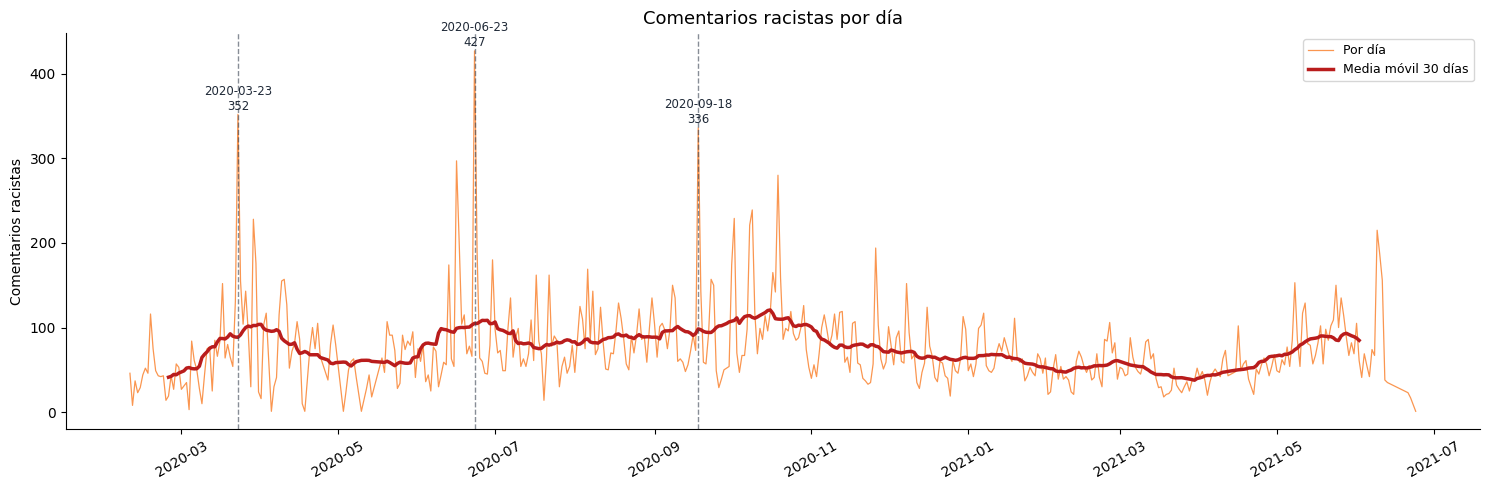

In [37]:
# Definicion de racism_daily
racism_daily = (tw_arg[tw_arg['RACISM'] == 1]
                .groupby('date_only').size()
                .reset_index(name='count'))
racism_daily['rolling_30'] = racism_daily['count'].rolling(30, center=True).mean()
racism_daily['date_dt'] = pd.to_datetime(racism_daily['date_only'])

# Serie temporal con top 3 picos
top_picos_r = racism_daily.nlargest(3, 'count')

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(racism_daily['date_dt'], racism_daily['count'],
        color='#f97316', linewidth=0.9, alpha=0.75, label='Por día')
ax.plot(racism_daily['date_dt'], racism_daily['rolling_30'],
        color='#b91c1c', linewidth=2.5, label='Media móvil 30 días')

for _, row in top_picos_r.iterrows():
    ax.axvline(row['date_dt'], color='#374151', linewidth=1, linestyle='--', alpha=0.6)
    ax.text(row['date_dt'], row['count'] + 2,
            f"{row['date_only']}\n{int(row['count']):,}",
            ha='center', va='bottom', fontsize=8.5, color='#1f2937')

ax.set_title('Comentarios racistas por día', fontsize=13)
ax.set_ylabel('Comentarios racistas')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

### 7.6. Picos secundarios de racismo

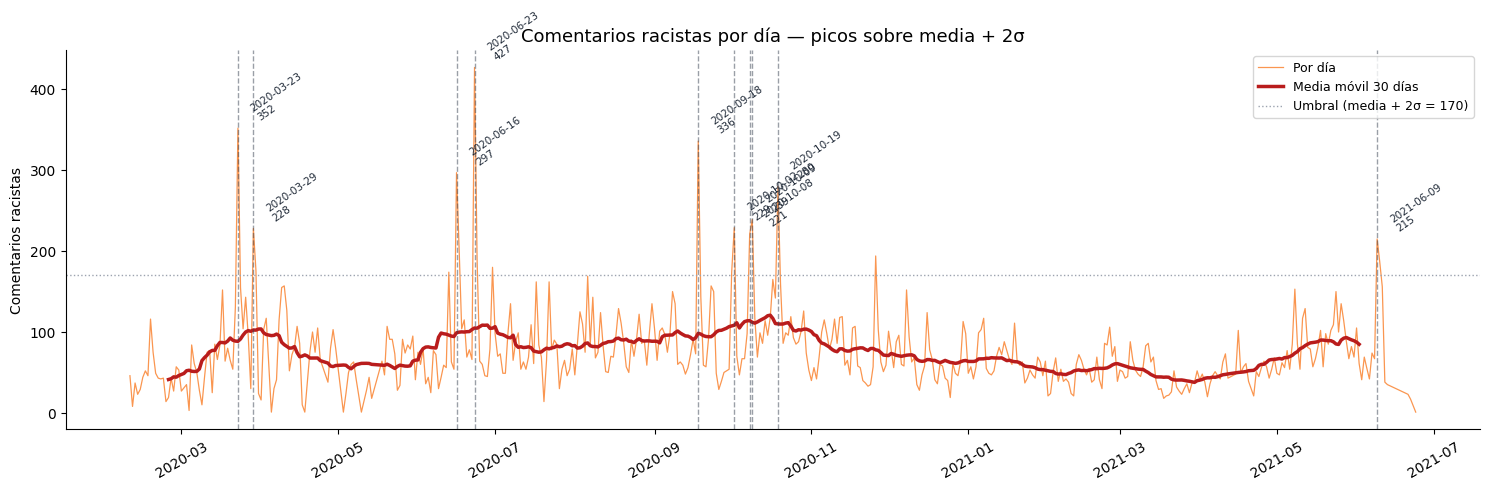

Días sobre el umbral: 18


In [38]:
# Picos secundarios de comentarios racistas (umbral: media + 2σ, top 10 etiquetados)
umbral_racism = racism_daily['count'].mean() + 2 * racism_daily['count'].std()
picos_racism = racism_daily[racism_daily['count'] >= umbral_racism].copy()
top10_racism = picos_racism.nlargest(10, 'count')

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(racism_daily['date_dt'], racism_daily['count'],
        color='#f97316', linewidth=0.9, alpha=0.75, label='Por día')
ax.plot(racism_daily['date_dt'], racism_daily['rolling_30'],
        color='#b91c1c', linewidth=2.5, label='Media móvil 30 días')
ax.axhline(umbral_racism, color='#9ca3af', linewidth=1, linestyle=':',
           label=f'Umbral (media + 2σ = {int(umbral_racism):,})')

for _, row in top10_racism.iterrows():
    ax.axvline(row['date_dt'], color='#374151', linewidth=1, linestyle='--', alpha=0.5)
    ax.annotate(f"{row['date_only']}\n{int(row['count']):,}",
                xy=(row['date_dt'], row['count']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=7.5, color='#1f2937',
                rotation=35, va='bottom')

ax.set_title('Comentarios racistas por día — picos sobre media + 2σ', fontsize=13)
ax.set_ylabel('Comentarios racistas')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
print(f"Días sobre el umbral: {len(picos_racism)}")

In [39]:
print("Fechas de los %d comentarios racistas sobre el umbral (media + 2σ):" % len(picos_racism))
for _, row in picos_racism.iterrows():
    print(f"  - {row['date_only']} con {int(row['count']):,} comentarios racistas")
    

Fechas de los 18 comentarios racistas sobre el umbral (media + 2σ):
  - 2020-03-23 con 352 comentarios racistas
  - 2020-03-29 con 228 comentarios racistas
  - 2020-03-30 con 176 comentarios racistas
  - 2020-06-13 con 174 comentarios racistas
  - 2020-06-16 con 297 comentarios racistas
  - 2020-06-17 con 204 comentarios racistas
  - 2020-06-23 con 427 comentarios racistas
  - 2020-06-24 con 190 comentarios racistas
  - 2020-06-30 con 180 comentarios racistas
  - 2020-09-18 con 336 comentarios racistas
  - 2020-10-01 con 174 comentarios racistas
  - 2020-10-02 con 229 comentarios racistas
  - 2020-10-08 con 221 comentarios racistas
  - 2020-10-09 con 239 comentarios racistas
  - 2020-10-19 con 280 comentarios racistas
  - 2020-11-26 con 194 comentarios racistas
  - 2021-06-09 con 215 comentarios racistas
  - 2021-06-10 con 187 comentarios racistas


### 7.7 Comparación fechas de picos de odio con picos de racismo

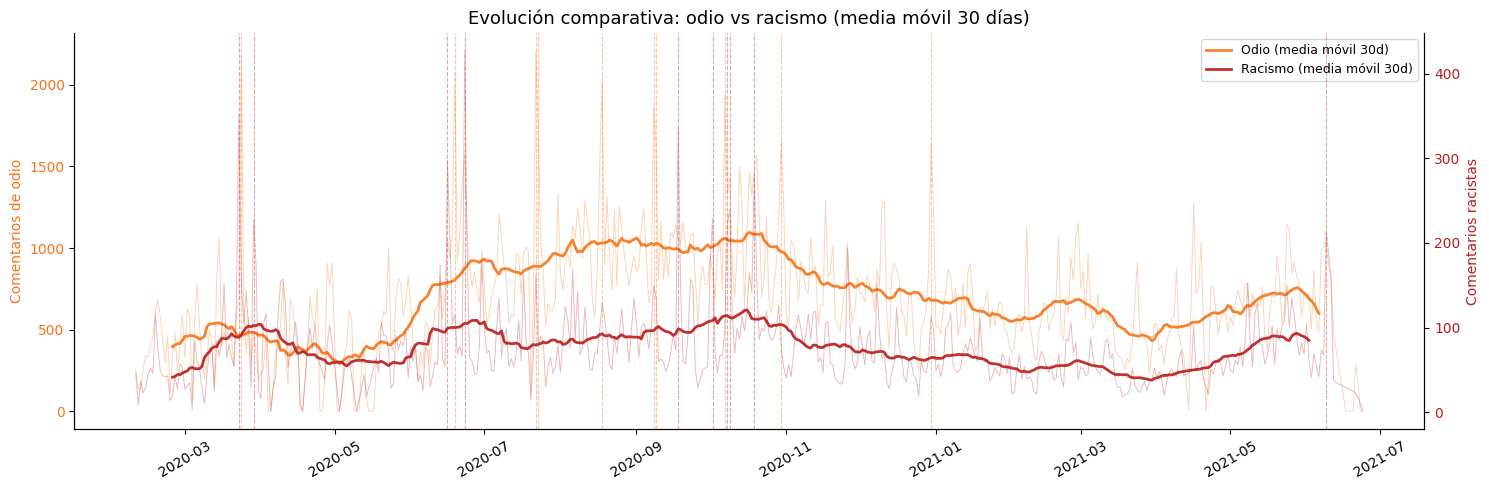

In [40]:
# Gráfico comparativo: picos de odio vs racismo en el mismo eje
fig, ax1 = plt.subplots(figsize=(15, 5))

ax2 = ax1.twinx()

ax1.plot(hate_daily_counts['date_dt'], hate_daily_counts['rolling_30'],
         color='#f97316', linewidth=2, label='Odio (media móvil 30d)', alpha=0.9)
ax1.plot(hate_daily_counts['date_dt'], hate_daily_counts['hate_tweet_count'],
         color='#f97316', linewidth=0.7, alpha=0.3)

ax2.plot(racism_daily['date_dt'], racism_daily['rolling_30'],
         color='#b91c1c', linewidth=2, label='Racismo (media móvil 30d)', alpha=0.9)
ax2.plot(racism_daily['date_dt'], racism_daily['count'],
         color='#b91c1c', linewidth=0.7, alpha=0.3)

for _, row in top10_hate.iterrows():
    ax1.axvline(row['date_dt'], color='#f97316', linewidth=0.8, linestyle='--', alpha=0.4)
for _, row in top10_racism.iterrows():
    ax2.axvline(row['date_dt'], color='#b91c1c', linewidth=0.8, linestyle='--', alpha=0.4)

ax1.set_ylabel('Comentarios de odio', color='#f97316')
ax2.set_ylabel('Comentarios racistas', color='#b91c1c')
ax1.tick_params(axis='y', labelcolor='#f97316')
ax2.tick_params(axis='y', labelcolor='#b91c1c')
ax1.tick_params(axis='x', rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

ax1.set_title('Evolución comparativa: odio vs racismo (media móvil 30 días)', fontsize=13)
sns.despine(right=False)
plt.tight_layout()
plt.show()



Aclaración: El gráfico usa doble eje Y: el eje izquierdo (naranja) corresponde a comentarios de odio total (HATEFUL) y el eje derecho (rojo) a comentarios racistas (RACISM). Las escalas son distintas por lo que la proximidad visual de las líneas no implica magnitudes similares, solo sirve para ver si se mueven de manera similar 

In [41]:

def match_picos(top_hate, top_racism, col_hate='hate_tweet_count', col_racism='count'):
    """Dias que aparecen en ambos tops (odio y racismo)."""
    fechas_hate   = set(top_hate['date_only'].astype(str))
    fechas_racism = set(top_racism['date_only'].astype(str))
    coincidencias = fechas_hate & fechas_racism

    if not coincidencias:
        print("Ningún día coincide entre los dos tops.")
        return

    print(f"Días en el top de odio Y racismo simultáneamente: {len(coincidencias)}\n")
    for fecha in sorted(coincidencias):
        h = top_hate[top_hate['date_only'].astype(str) == fecha].iloc[0]
        r = top_racism[top_racism['date_only'].astype(str) == fecha].iloc[0]
        print(f"  {fecha}  —  odio: {int(h[col_hate]):,}  |  racismo: {int(r[col_racism]):,}")

match_picos(top10_hate, top10_racism)

Ningún día coincide entre los dos tops.


Observación:
Las fechas de los picos en los graficos son diferentes, en particular el top 3 queda de la siguiente manera:
- Para los comentarios de odio los picos son el 24 de marzo, 19 de junio y el 22 de julio de 2020
- Para los comentarios racistas los picos son el 23 de marzo, el 23 de junio y el 18 de septiembre de 2020

Estaria bueno ver las noticias de estas fechas en el EDA2 para analizar el contenido de los comentarios

### 7.8. Para cada fecha pico: noticia más comentada + muestra de comentarios

In [42]:
print("=" * 80)
print("PICOS DE ODIO — NOTICIAS Y COMENTARIOS")
print("=" * 80)

for _, row in top10_hate.iterrows():
    fecha = row['date_only']
    dia = tw_arg[(tw_arg['date_only'] == fecha) & (tw_arg['HATEFUL'] == 1)]

    top_noticia = (dia.groupby('tweet_id_noticia')
                     .agg(n=('id', 'count'), title=('title', 'first'), resumen=('resumen', 'first'))
                     .nlargest(1, 'n').iloc[0])
    link = str(top_noticia['resumen']).split()[-1]

    print(f"\n{'─'*80}")
    print(f"  Fecha   : {fecha}  |  Comentarios de odio ese día: {int(row['hate_tweet_count']):,}")
    print(f"  Noticia : {top_noticia['title']}")
    print(f"  Link    : {link}  [{int(top_noticia['n'])} com. odio]")
    print(f"  Muestra de comentarios:")
    muestra = dia[dia['tweet_id_noticia'] == top_noticia.name]['text'].sample(
        min(3, int(top_noticia['n'])), random_state=42)
    for c in muestra:
        print(f"    · {c}")


PICOS DE ODIO — NOTICIAS Y COMENTARIOS

────────────────────────────────────────────────────────────────────────────────
  Fecha   : 2020-07-22  |  Comentarios de odio ese día: 2,208
  Noticia : “Mi hijo se quedó sin papá gracias a este señor”, el reproche de la ex del ladrón muerto
  Link    : https://t.co/Ggesl9STjO  [310 com. odio]
  Muestra de comentarios:
    · @clarincom Si y nuestro país se quedó con una basura menos!!!
    · @clarincom Dale gracias al jubilado que le evito a tu bendición tener de ejemplo un delincuente ena familia.
    · @clarincom Faltan balas en algunos lados

────────────────────────────────────────────────────────────────────────────────
  Fecha   : 2020-03-24  |  Comentarios de odio ese día: 2,184
  Noticia : Estela Carlotto y el coronavirus: "Si hubiera estado el gobierno anterior no sé cuántos moriríamos"
  Link    : https://t.co/OcKoJwV84T  [562 com. odio]
  Muestra de comentarios:
    · @LANACION Vieja de MIERDA
    · @LANACION Vieja de mierda. Solo de

In [43]:
print("PICOS DE RACISMO — NOTICIAS Y COMENTARIOS")
print("=" * 80)

for _, row in top10_racism.iterrows():
    fecha = row['date_only']
    dia = tw_arg[(tw_arg['date_only'] == fecha) & (tw_arg['RACISM'] == 1)]

    top_noticia = (dia.groupby('tweet_id_noticia')
                     .agg(n=('id', 'count'), title=('title', 'first'), resumen=('resumen', 'first'))
                     .nlargest(1, 'n').iloc[0])
    link = str(top_noticia['resumen']).split()[-1]

    print(f"\n{'─'*80}")
    print(f"  Fecha   : {fecha}  |  Comentarios racistas ese día: {int(row['count']):,}")
    print(f"  Noticia : {top_noticia['title']}")
    print(f"  Link    : {link}  [{int(top_noticia['n'])} com. racistas]")
    print(f"  Muestra de comentarios:")
    muestra = dia[dia['tweet_id_noticia'] == top_noticia.name]['text'].sample(
        min(3, int(top_noticia['n'])), random_state=42)
    for c in muestra:
        print(f"    · {c}")

PICOS DE RACISMO — NOTICIAS Y COMENTARIOS

────────────────────────────────────────────────────────────────────────────────
  Fecha   : 2020-06-23  |  Comentarios racistas ese día: 427
  Noticia : China: comenzó el tradicional Festival de carne de perro a pesar de la pandemia de coronavirus
  Link    : https://t.co/MXn609BUzE  [78 com. racistas]
  Muestra de comentarios:
    · @LANACION Noo pero estos HDP  no son humanos!!!
Ni los animales son tan asquerosos para comer...
    · @LANACION QUE ES ESTRO HIJO DE PUTA, BORRAR INFORME YA. Y QUE MUERAN LOS CHINO DE PUTA
    · @LANACION Estos HDP merecen extinguirse.

────────────────────────────────────────────────────────────────────────────────
  Fecha   : 2020-03-23  |  Comentarios racistas ese día: 352
  Noticia : Tres extranjeros incumplían la cuarentena total y agredieron a los policías que quisieron identificarlos
  Link    : https://t.co/r40lhweP5P  [252 com. racistas]
  Muestra de comentarios:
    · @infobae Que los manden a su País 

### 7.9. Serie temporal de comentarios racistas por medio

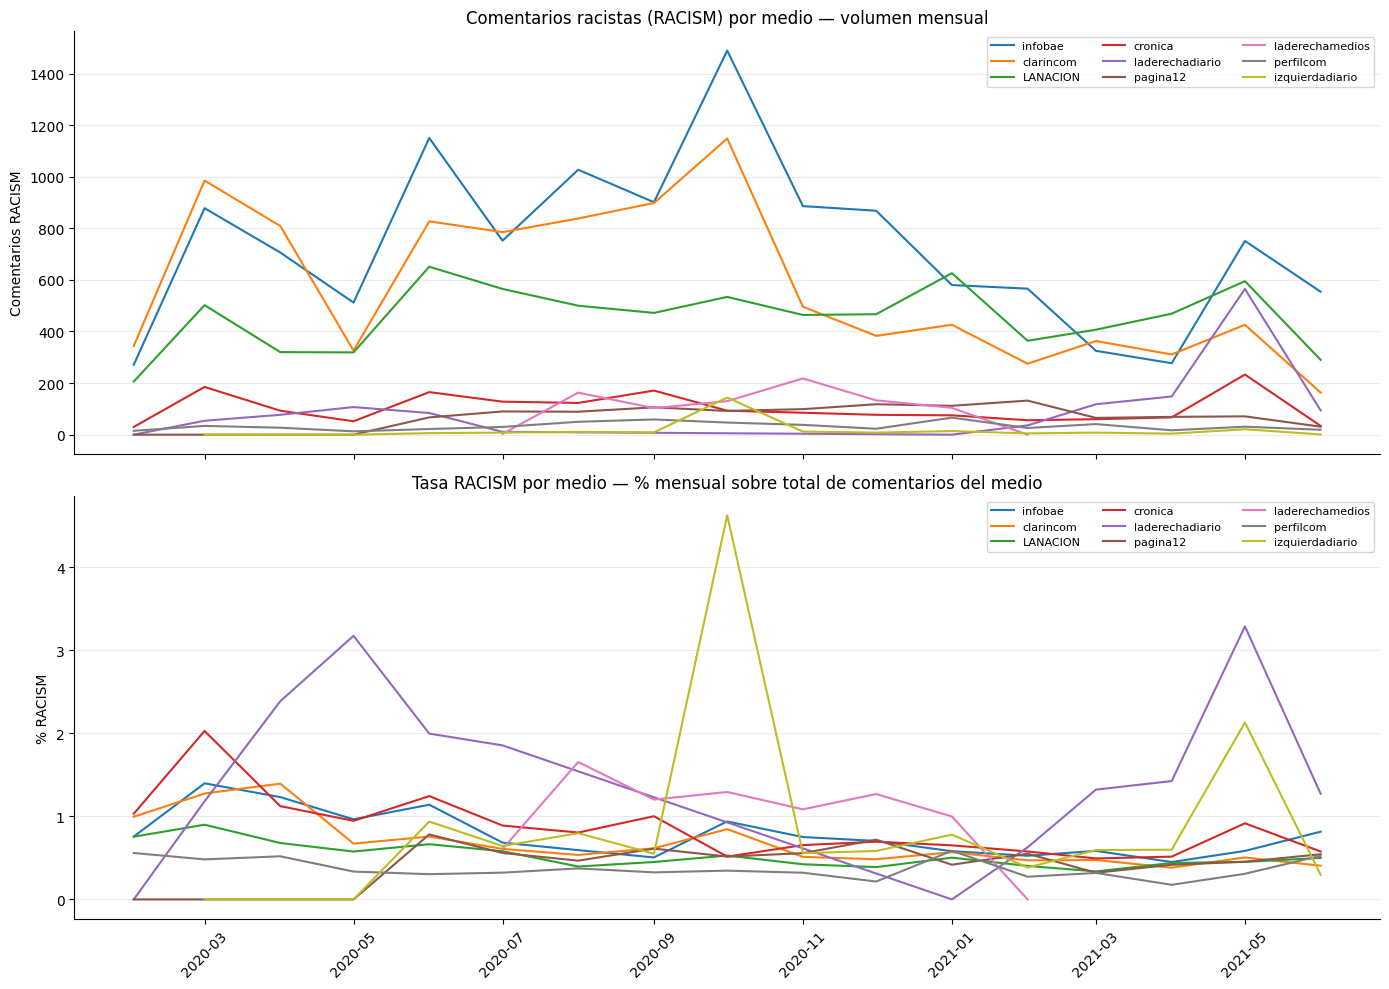

In [44]:

tw_arg['date_tweet'] = pd.to_datetime(tw_arg['date_tweet'])
tw_arg['mes'] = tw_arg['date_tweet'].dt.to_period('M')

# Por medio por mes
total_por_medio_mes   = tw_arg.groupby(['medio', 'mes']).size().reset_index(name='total')
racism_por_medio_mes  = tw_arg[tw_arg['RACISM']  == 1].groupby(['medio', 'mes']).size().reset_index(name='racism')
hateful_por_medio_mes = tw_arg[tw_arg['HATEFUL'] == 1].groupby(['medio', 'mes']).size().reset_index(name='hateful')

df_ts = (total_por_medio_mes
         .merge(racism_por_medio_mes,  on=['medio', 'mes'], how='left')
         .merge(hateful_por_medio_mes, on=['medio', 'mes'], how='left')
         .fillna(0))
df_ts['tasa_racism']  = df_ts['racism']  / df_ts['total'] * 100
df_ts['tasa_hateful'] = df_ts['hateful'] / df_ts['total'] * 100
df_ts['fecha'] = df_ts['mes'].dt.to_timestamp()

# Orden de medios por volumen total de RACISM
orden_medios = (
    df_ts.groupby('medio')['racism'].sum()
    .sort_values(ascending=False)
    .index.tolist()
)

palette   = sns.color_palette('tab10', n_colors=len(orden_medios))
color_map = dict(zip(orden_medios, palette))

# Gráfico 1: RACISM
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for medio in orden_medios:
    d = df_ts[df_ts['medio'] == medio]
    axes[0].plot(d['fecha'], d['racism'], label=medio, color=color_map[medio], linewidth=1.5)
axes[0].set_title('Comentarios racistas (RACISM) por medio — volumen mensual', fontsize=12)
axes[0].set_ylabel('Comentarios RACISM')
axes[0].legend(fontsize=8, ncol=3, loc='upper right')
axes[0].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[0])

for medio in orden_medios:
    d = df_ts[df_ts['medio'] == medio]
    axes[1].plot(d['fecha'], d['tasa_racism'], label=medio, color=color_map[medio], linewidth=1.5)
axes[1].set_title('Tasa RACISM por medio — % mensual sobre total de comentarios del medio', fontsize=12)
axes[1].set_ylabel('% RACISM')
axes[1].legend(fontsize=8, ncol=3, loc='upper right')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


### 7.10. Serie temporal de comentarios  de odio por medio

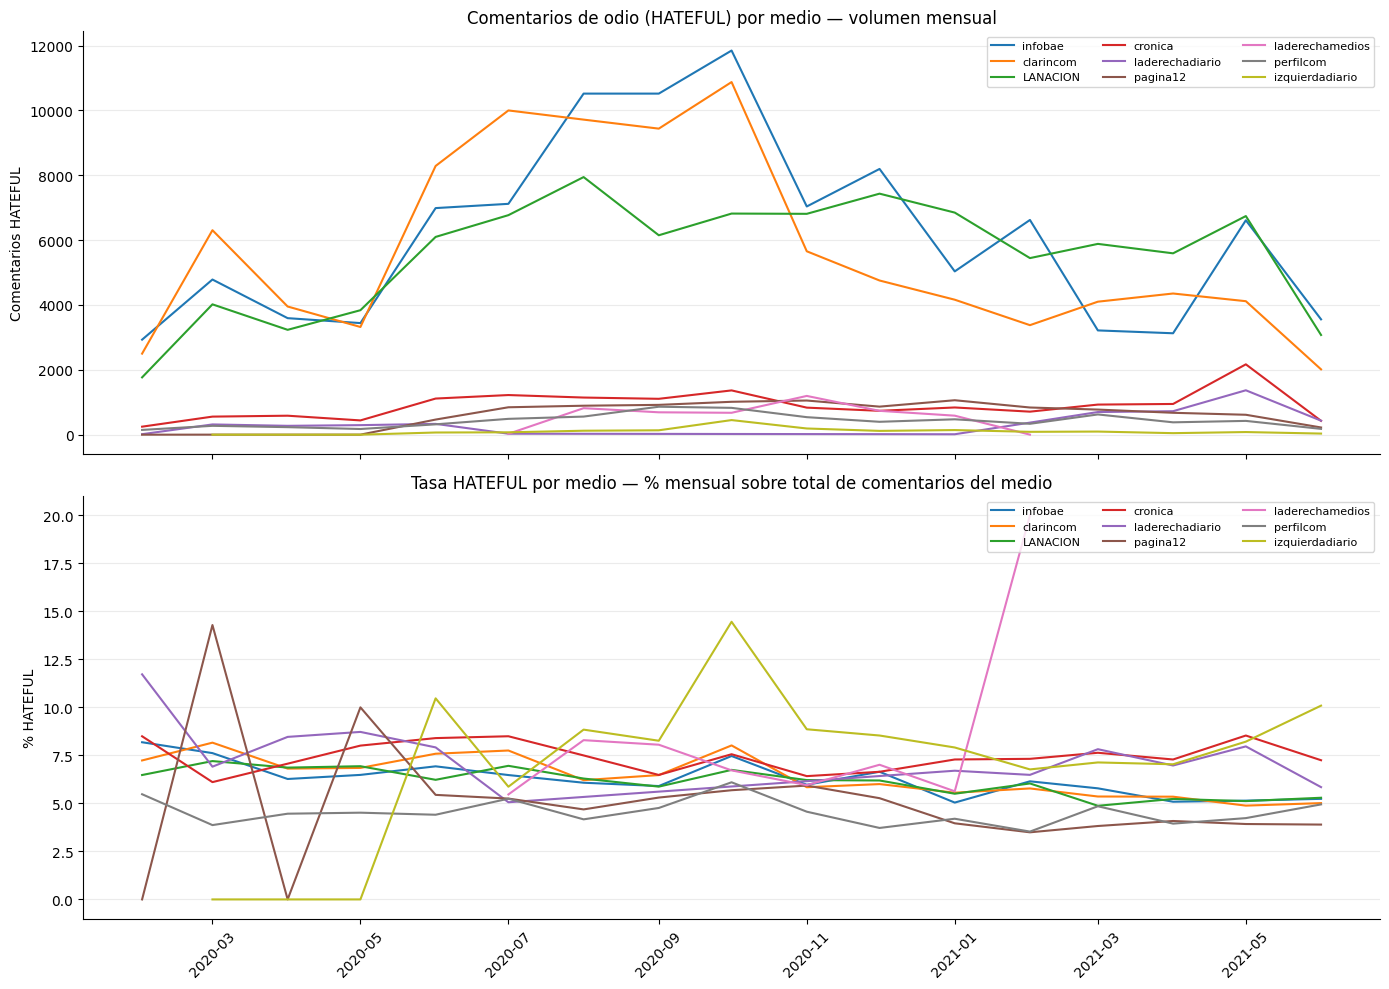

In [45]:

# Gráfico 2: HATEFUL
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for medio in orden_medios:
    d = df_ts[df_ts['medio'] == medio]
    axes[0].plot(d['fecha'], d['hateful'], label=medio, color=color_map[medio], linewidth=1.5)
axes[0].set_title('Comentarios de odio (HATEFUL) por medio — volumen mensual', fontsize=12)
axes[0].set_ylabel('Comentarios HATEFUL')
axes[0].legend(fontsize=8, ncol=3, loc='upper right')
axes[0].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[0])

for medio in orden_medios:
    d = df_ts[df_ts['medio'] == medio]
    axes[1].plot(d['fecha'], d['tasa_hateful'], label=medio, color=color_map[medio], linewidth=1.5)
axes[1].set_title('Tasa HATEFUL por medio — % mensual sobre total de comentarios del medio', fontsize=12)
axes[1].set_ylabel('% HATEFUL')
axes[1].legend(fontsize=8, ncol=3, loc='upper right')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


### 7.11. Ranking de meses por comentarios racistas y de odio

Se analiza si octubre es realmente el mes con mayor volumen de comentarios racistas (RACISM=1) y de odio en general (cualquier etiqueta de odio = 1), tanto en términos absolutos como en tasa.

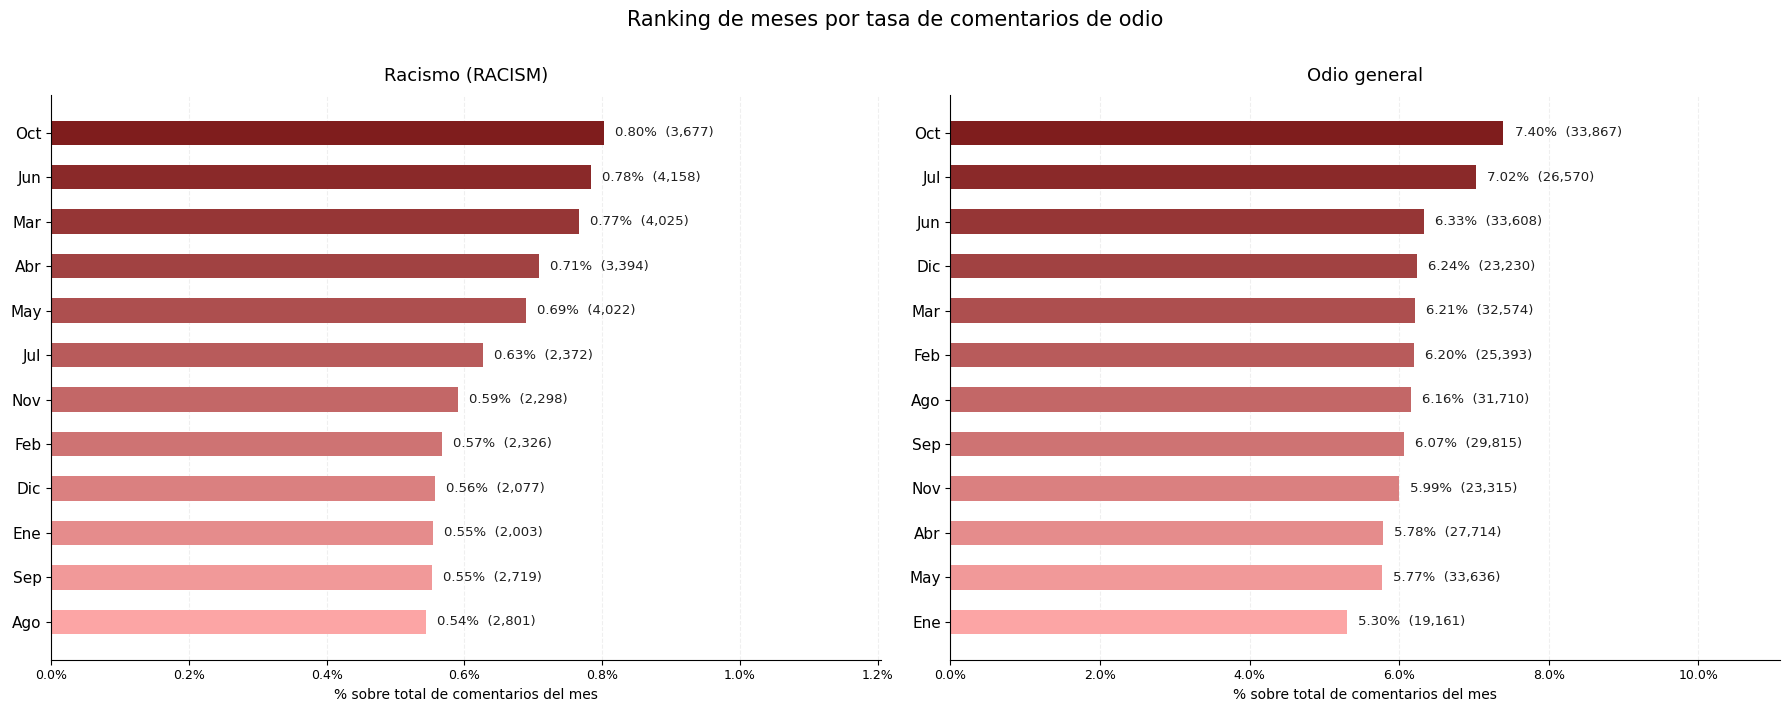

Mes con mas comentarios racistas (abs): Jun (4,158)
Mes con mas odio general (abs):         Oct (33,867)
Mes con mayor tasa de racism:           Oct (0.80%)
Mes con mayor tasa de odio:             Oct (7.40%)


In [46]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

HATE_COLS = ['HATEFUL', 'CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS',
             'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']

meses_es = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

tw_arg['mes'] = tw_arg['date_tweet'].dt.month

monthly = (
    tw_arg.groupby('mes')
    .agg(
        total=('id', 'count'),
        racistas=('RACISM', 'sum'),
        odio=('HATEFUL', lambda x: (tw_arg.loc[x.index, HATE_COLS].max(axis=1) == 1).sum())
    )
    .assign(
        tasa_racism=lambda df: df['racistas'] / df['total'] * 100,
        tasa_odio=lambda df: df['odio'] / df['total'] * 100,
        mes_nombre=lambda df: df.index.map(meses_es)
    )
    .reset_index()
)

# Paleta rojo oscuro → salmon
cmap = LinearSegmentedColormap.from_list('rojo_salmon', ['#fca5a5', '#7f1d1d'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Ranking de meses por tasa de comentarios de odio', fontsize=15, y=1.01)

for ax, col_tasa, col_abs, title in [
    (ax1, 'tasa_racism', 'racistas', 'Racismo (RACISM)'),
    (ax2, 'tasa_odio',   'odio',     'Odio general'),
]:
    df = monthly.sort_values(col_tasa, ascending=True).reset_index(drop=True)
    max_val = df[col_tasa].max()
    n = len(df)

    # Color por rango: el más alto (último) recibe el rojo más oscuro
    colors = [cmap(i / (n - 1)) for i in range(n)]

    bars = ax.barh(df['mes_nombre'], df[col_tasa], color=colors, height=0.55)

    for i, row in df.iterrows():
        ax.text(row[col_tasa] + max_val * 0.02, i,
                f"{row[col_tasa]:.2f}%  ({int(row[col_abs]):,})",
                va='center', fontsize=9.5, color='#1f1f1f')

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('% sobre total de comentarios del mes', fontsize=10)
    ax.set_xlim(0, max_val * 1.5)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.grid(axis='x', alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Resumen
top_r = monthly.loc[monthly['racistas'].idxmax()]
top_o = monthly.loc[monthly['odio'].idxmax()]
print(f"Mes con mas comentarios racistas (abs): {meses_es[top_r['mes']]} ({int(top_r['racistas']):,})")
print(f"Mes con mas odio general (abs):         {meses_es[top_o['mes']]} ({int(top_o['odio']):,})")
print(f"Mes con mayor tasa de racism:           {meses_es[monthly.loc[monthly['tasa_racism'].idxmax(), 'mes']]} ({monthly['tasa_racism'].max():.2f}%)")
print(f"Mes con mayor tasa de odio:             {meses_es[monthly.loc[monthly['tasa_odio'].idxmax(), 'mes']]} ({monthly['tasa_odio'].max():.2f}%)")


### 7.12. Tasa de racismo por medio en octubre

Se analiza qué proporción de los comentarios de cada medio en octubre son racistas (RACISM=1), comparando entre medios. En particular se ve octubre porque se ve un pico en ese periodo

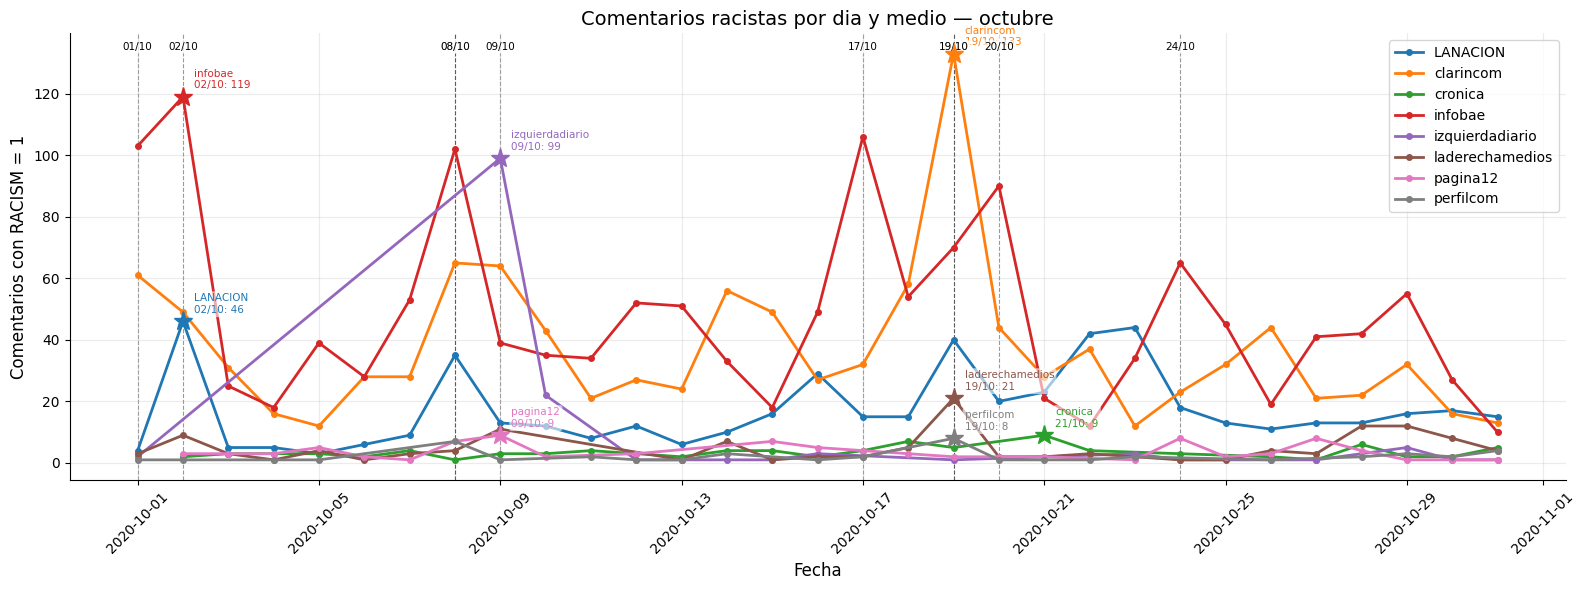

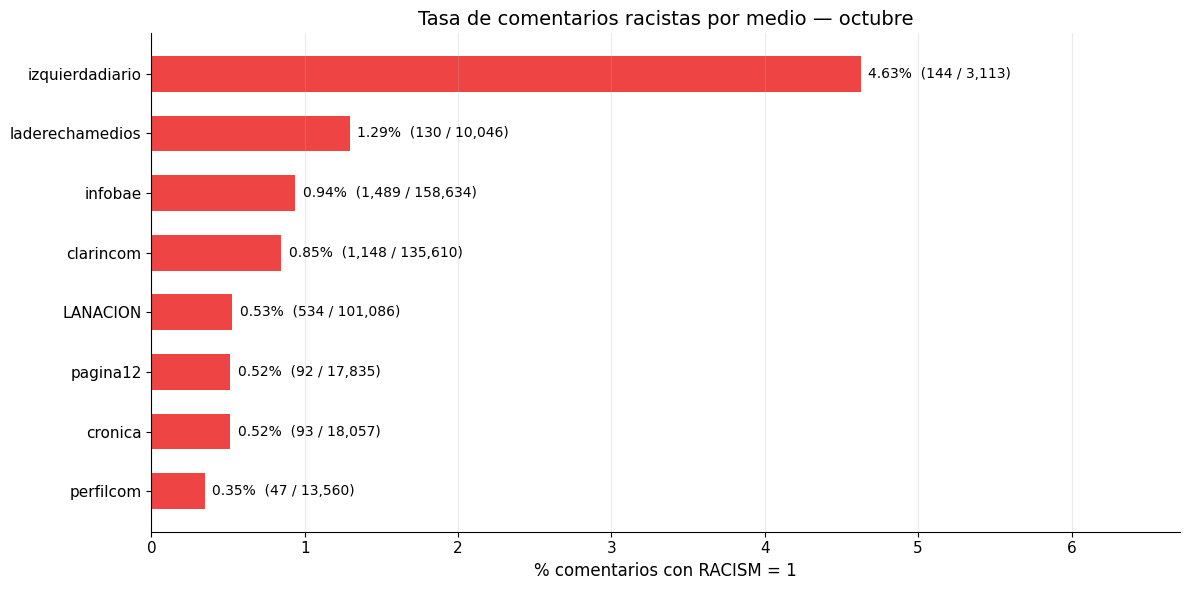

Medio con mayor tasa de racismo en octubre: izquierdadiario (4.63%)


In [47]:
# Filtrar octubre (todos los años presentes en el dataset)
octubre = tw_arg[tw_arg['date_tweet'].dt.month == 10].copy()

# Tasa de racismo por medio en octubre
tasa_oct = (
    octubre.groupby('medio')
    .agg(total=('id', 'count'), racistas=('RACISM', 'sum'))
    .assign(tasa_pct=lambda df: df['racistas'] / df['total'] * 100)
    .sort_values('tasa_pct', ascending=True)
    .reset_index()
)

# Conteo diario de comentarios racistas por medio en octubre
daily_racism = (
    octubre[octubre['RACISM'] == 1]
    .assign(fecha=octubre['date_tweet'].dt.date)
    .groupby(['fecha', 'medio'])
    .size()
    .reset_index(name='n_racistas')
)
daily_racism['fecha'] = pd.to_datetime(daily_racism['fecha'])

# Top 10 picos globales
top10 = daily_racism.nlargest(10, 'n_racistas')

# --- Grafico 1: conteo diario por medio con picos anotados ---
fig, ax1 = plt.subplots(figsize=(16, 6))

palette = sns.color_palette('tab10', n_colors=daily_racism['medio'].nunique())
medios_ordenados = sorted(daily_racism['medio'].unique())
for i, medio in enumerate(medios_ordenados):
    sub = daily_racism[daily_racism['medio'] == medio].sort_values('fecha')
    ax1.plot(sub['fecha'], sub['n_racistas'], marker='o', markersize=4,
             label=medio, color=palette[i], linewidth=2)

    # Pico de cada medio
    idx_max = sub['n_racistas'].idxmax()
    pico = sub.loc[idx_max]
    ax1.plot(pico['fecha'], pico['n_racistas'], marker='*', markersize=14,
             color=palette[i], zorder=5)
    ax1.annotate(f"{medio}\n{pico['fecha'].strftime('%d/%m')}: {int(pico['n_racistas'])}",
                 xy=(pico['fecha'], pico['n_racistas']),
                 xytext=(8, 6), textcoords='offset points',
                 fontsize=7.5, color=palette[i],
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

# Top 10 picos globales: linea vertical + fecha
for _, row in top10.iterrows():
    ax1.axvline(row['fecha'], color='black', linewidth=0.8, linestyle='--', alpha=0.4, zorder=1)
    ax1.text(row['fecha'], ax1.get_ylim()[1] * 0.98,
             row['fecha'].strftime('%d/%m'),
             ha='center', va='top', fontsize=7.5,
             color='black',
             bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, ec='none'))

ax1.set_title('Comentarios racistas por dia y medio — octubre', fontsize=14)
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Comentarios con RACISM = 1', fontsize=12)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(axis='both', alpha=0.25)
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
sns.despine()
plt.tight_layout()
plt.show()

# --- Grafico 2: tasa de racismo por medio ---
fig, ax2 = plt.subplots(figsize=(12, 6))

ax2.barh(tasa_oct['medio'], tasa_oct['tasa_pct'], color='#ef4444', height=0.6)
for i, (_, row) in enumerate(tasa_oct.iterrows()):
    ax2.text(row['tasa_pct'] + 0.05, i,
             f"{row['tasa_pct']:.2f}%  ({int(row['racistas']):,} / {int(row['total']):,})",
             va='center', fontsize=10)

ax2.set_title('Tasa de comentarios racistas por medio — octubre', fontsize=14)
ax2.set_xlabel('% comentarios con RACISM = 1', fontsize=12)
ax2.set_xlim(0, tasa_oct['tasa_pct'].max() * 1.45)
ax2.tick_params(axis='both', labelsize=11)
ax2.grid(axis='x', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Medio con mayor tasa
top_medio = tasa_oct.iloc[-1]
print(f"Medio con mayor tasa de racismo en octubre: {top_medio['medio']} ({top_medio['tasa_pct']:.2f}%)")


In [48]:
# Noticia con más comentarios racistas en octubre + muestra de comentarios
top_noticia_oct = (
    octubre[octubre['RACISM'] == 1]
    .groupby('tweet_id_noticia')
    .agg(n_racism=('id', 'count'), title=('title', 'first'),
         resumen=('resumen', 'first'), medio=('medio', 'first'),
         fecha=('date_tweet', 'min'))
    .nlargest(1, 'n_racism')
    .iloc[0]
)
link = str(top_noticia_oct['resumen']).split()[-1]

print(f"Noticia con más comentarios racistas en octubre:")
print(f"  Medio    : {top_noticia_oct['medio']}")
print(f"  Fecha    : {top_noticia_oct['fecha'].date()}")
print(f"  Titulo   : {top_noticia_oct['title']}")
print(f"  Link     : {link}")
print(f"  Com. RACISM: {int(top_noticia_oct['n_racism']):,}")

print(f"\nMuestra de comentarios racistas:")
muestra = (octubre[(octubre['tweet_id_noticia'] == top_noticia_oct.name) &
                   (octubre['RACISM'] == 1)]['text']
           .sample(min(5, int(top_noticia_oct['n_racism'])), random_state=42))
for c in muestra:
    print(f"  · {c}")

Noticia con más comentarios racistas en octubre:
  Medio    : izquierdadiario
  Fecha    : 2020-10-09
  Titulo   : El Ejército invadió tierras pertenecientes a una comunidad mapuche en Bariloche
  Link     : https://t.co/U1ew7a0TPn
  Com. RACISM: 121

Muestra de comentarios racistas:
  · @izquierdadiario Héroes.
  · @izquierdadiario Algún intoxicado con plomo?
  · @izquierdadiario Recuperó*
Zurdos del orto
  · @izquierdadiario Les faltó cagarlos bien a tiros a los negros de mierda.
  · @izquierdadiario Hermoso. Deberían tirotearlos si aparecen!


## 8. Usuarios reincidentes en comentarios racistas

Se identifican los usuarios que realizaron más de un comentario con `RACISM = 1`. Luego se analizan los comentarios realizados y un perfil del usuiario con todas las etiquetas para ver si el odio es particularmente racista o si tambien ejercen otros tipos de odio

### 8.1. Usuarios racistas

In [49]:
#Separo solo los comentarios racistas para analizar la distribución por usuario
df_racist = tw_arg[tw_arg['RACISM'] == 1].copy()

comentarios_por_usuario = df_racist.groupby('user_id').size().reset_index(name='n_comentarios') 


total_usuarios  = len(comentarios_por_usuario) 
usuarios_1      = (comentarios_por_usuario['n_comentarios'] == 1).sum() 
usuarios_2_5    = comentarios_por_usuario['n_comentarios'].between(2, 5).sum()
usuarios_6_plus = (comentarios_por_usuario['n_comentarios'] > 5).sum()

print(f"Comentarios racistas totales : {len(df_racist):}")
print(f"Usuarios únicos              : {total_usuarios:}")
print(f"  — Usuarios con 1 comentario            : {usuarios_1:}  ({usuarios_1/total_usuarios*100:.1f}%)")
print(f"  — Usuarios con 2 a 5 comentarios        : {usuarios_2_5:}  ({usuarios_2_5/total_usuarios*100:.1f}%)")
print(f"  — Usuarios con más de 5 comentarios     : {usuarios_6_plus:}  ({usuarios_6_plus/total_usuarios*100:.1f}%)")
print()

# Comentarios generados por reincidentes
comentarios_reincidentes = (comentarios_por_usuario[comentarios_por_usuario['n_comentarios'] > 1]).sum()['n_comentarios']
print(f"Comentarios generados por usuarios con más de 1 tweet racista: "
      f"{comentarios_reincidentes:} ({comentarios_reincidentes/len(df_racist)*100:.1f}% del total)")


Comentarios racistas totales : 35872
Usuarios únicos              : 20047
  — Usuarios con 1 comentario            : 14397  (71.8%)
  — Usuarios con 2 a 5 comentarios        : 4877  (24.3%)
  — Usuarios con más de 5 comentarios     : 773  (3.9%)

Comentarios generados por usuarios con más de 1 tweet racista: 21475 (59.9% del total)


### 8.2. Usuarios racistas reincidentes


In [50]:
# Top reincidentes: resumen por usuario
top_reincidentes = (
    comentarios_por_usuario
    .nlargest(10, 'n_comentarios')
    .merge(
        df_racist.groupby('user_id').agg(
            n_noticias=('tweet_id_noticia', 'nunique'),
            n_medios=('medio', 'nunique'),
            medios=('medio', lambda x: ', '.join(sorted(x.unique())))
        ).reset_index(),
        on='user_id'
    )
)
print("Top 10 usuarios con más comentarios racistas:")
print(top_reincidentes[['user_id','n_comentarios','n_noticias','n_medios','medios']].to_string(index=False))


Top 10 usuarios con más comentarios racistas:
            user_id  n_comentarios  n_noticias  n_medios                                            medios
         4819881863             97          97         5 LANACION, clarincom, infobae, pagina12, perfilcom
1304054864465530881             84          83         4           LANACION, clarincom, infobae, perfilcom
         4234373379             62          62         3                      LANACION, clarincom, infobae
1217504583947296769             61          61         5   LANACION, clarincom, cronica, infobae, pagina12
1184956448784211968             58          58         4             LANACION, clarincom, cronica, infobae
1191123861556940801             58          58         4            LANACION, clarincom, cronica, pagina12
         1532596098             52          50         4           LANACION, clarincom, infobae, perfilcom
 735477312083238912             52          52         2                                clarincom,

In [51]:
# Comentarios reales de cada usuario del top 10
for _, row in top_reincidentes.iterrows():
    uid = row['user_id']
    user_tweets = df_racist[df_racist['user_id'] == uid][['text', 'tweet_id_noticia', 'title', 'resumen', 'date_tweet']].copy()
    print(f"── user_id: {uid}  ({len(user_tweets)} comentarios) ──────────────────")
    print(f"_____________________________________________________________")
    for _, t in user_tweets.iterrows():
        link = str(t['resumen']).split()[-1] if pd.notna(t['resumen']) else 'sin link'
        titulo = str(t['title'])[:80] if pd.notna(t['title']) else 'sin titulo'
        print(f"  [{t['date_tweet'].date()}] {t['text']}")
        print(f"    Noticia : {titulo}")
        print(f"    Link    : {link}")
    print()


── user_id: 4819881863  (97 comentarios) ──────────────────
_____________________________________________________________
  [2021-04-01] @clarincom El bufon más barato que encontraron los perukas para actuar por unas migajas, es un arrastrado e imagino la enseñanza hacia su familia.
    Noticia : El descargo de Coco Sily tras su amenaza a Fernando Iglesias: “No me voy a arrep
    Link    : https://t.co/jwboR5pGr3
  [2021-04-29] @clarincom Estan podridos de alma de nacimientos, ustedes los perukas.
    Noticia : Otra crítica de Axel Kicillof a la Ciudad: “Ya nos tienen un poco podridos con a
    Link    : https://t.co/G9JpJ8KCmG
  [2021-04-29] @clarincom Jajajaaj estos perukas investigando a alguien por robar?? Es de película
    Noticia : Nueva embestida contra el procurador Eduardo Casal: el oficialismo lo quiere inv
    Link    : https://t.co/pIK83rUfoe
  [2021-05-09] @perfilcom @nievaleo Con qué poca cosa los alegran a la especie comepolenta y usurpadora.jajaj sigan revolviendo y cu

### 8.3. Perfil completo de los usuarios del top 10

Para cada usuario del top 10 se toman todos sus comentarios en el dataset (no solo los racistas) y se calcula cuántos tienen en cada etiqueta. Se busca ver si son usuarios con un patrón específico de racismo o si tambien presentan otros tipos de odio.

In [52]:
# Perfil completo en el dataset de los usuarios del top 10

top_ids = top_reincidentes['user_id'].tolist()
todos = tw_arg[tw_arg['user_id'].isin(top_ids)]

perfil = (
    todos.groupby('user_id')
    .agg(total_comentarios=('id', 'count'), **{e: (e, 'sum') for e in etiquetas})
    .reset_index()
)

# Calcular % de cada etiqueta sobre el total de comentarios del usuario
for e in etiquetas:
    perfil[f'%_{e}'] = (perfil[e] / perfil['total_comentarios'] * 100).round(1)

perfil = perfil.merge(top_reincidentes[['user_id', 'n_comentarios']], on='user_id')
perfil = perfil.rename(columns={'n_comentarios': 'racism_count'}).sort_values('racism_count', ascending=False)

# Tabla de conteos absolutos
print("Conteos absolutos por etiqueta (todos los comentarios del usuario en el dataset):")
cols_abs = ['user_id', 'total_comentarios'] + etiquetas
print(perfil[cols_abs].to_string(index=False))

print()

# Tabla de porcentajes
print("Porcentaje de comentarios con cada etiqueta:")
cols_pct = ['user_id', 'total_comentarios'] + [f'%_{e}' for e in etiquetas]
print(perfil[cols_pct].to_string(index=False))


Conteos absolutos por etiqueta (todos los comentarios del usuario en el dataset):
            user_id  total_comentarios  HATEFUL  CALLS  WOMEN  LGBTI  RACISM  CLASS  POLITICS  DISABLED  APPEARANCE  CRIMINAL
         4819881863               1159      166      1      5      3      97     22       109        24          17         1
1304054864465530881                306      115      0      7      2      84      4        16         5           6         0
         4234373379               1851      413      7     69     50      62     11       117        68         115        22
1217504583947296769               3500      242     23     29     18      61     45        34        32          50        21
1191123861556940801               1106      194      7      0      4      58      7       123         2          31         3
1184956448784211968                848      168      8     18      8      58     27        49        22          44        17
 990352152563417088               28

Puede que en el contexto de los comentarios peruka hable de algo mas politico relacionado al peronismo y no necesariamente de un ataque a personas de nacionalidad peruana. Esta observacion es viendo el caso del usuario 4819881863 que si se leen los comentarios que hizo se ve un uso abusivo de la palabra "peruka" pero viendo el perfil completo se ve que tiende a atacar en relación a la política.

## 9. Distribución horaria del odio y el racismo

Se analiza en qué franja horaria se concentran los comentarios de odio y racistas. Se muestran dos análisis:
- Volumen absoluto: cuántos comentarios con esa etiqueta se publicaron en cada hora.
- % deñ total: qué proporción de los comentarios publicados en esa hora tienen la etiqueta

### 9.1. Comentarios por hora

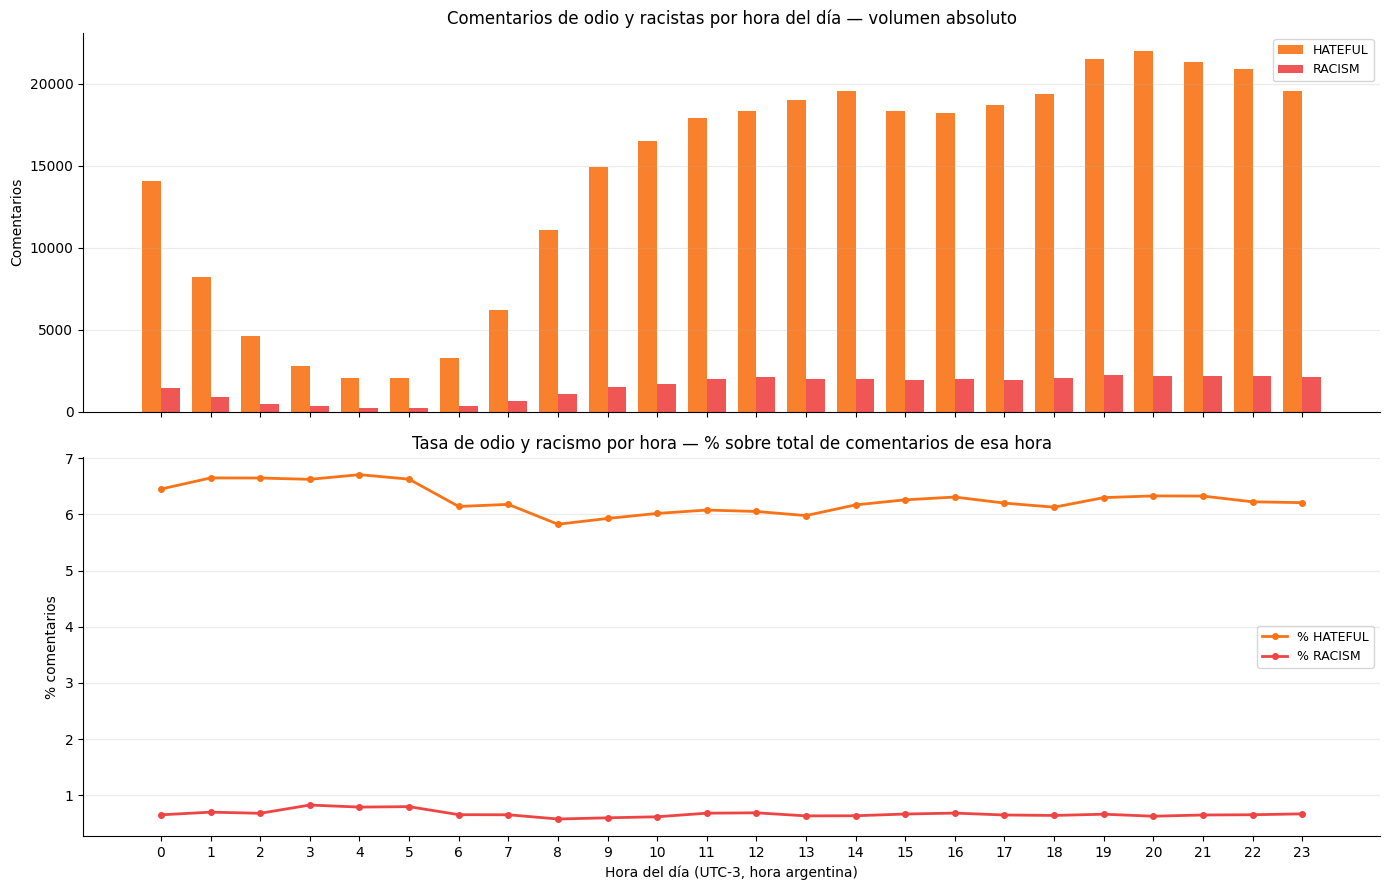

Hora con más comentarios HATEFUL (absoluto): 20hs  (22,014 comentarios)
Hora con más comentarios RACISM  (absoluto): 19hs  (2,263 comentarios)
Hora con mayor tasa HATEFUL:  4hs  (6.71%)
Hora con mayor tasa RACISM:   3hs  (0.83%)


In [53]:

# Distribución horaria de odio y racismo
tw_arg['date_tweet'] = pd.to_datetime(tw_arg['date_tweet'])

# Convertir UTC a UTC-3 (Argentina) para considerar la hora local de publicación del comentario
tw_arg['hora'] = (tw_arg['date_tweet'] - pd.Timedelta(hours=3)).dt.hour 

por_hora = tw_arg.groupby('hora').agg(
    total=('id', 'count'), 
    hateful=('HATEFUL', 'sum'),
    racism=('RACISM', 'sum')
).reset_index() #id es el identificador de cada comentario, por eso lo contamos para obtener el total de comentarios por hora

por_hora['tasa_hateful'] = por_hora['hateful'] / por_hora['total'] * 100
por_hora['tasa_racism']  = por_hora['racism']  / por_hora['total'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
horas = por_hora['hora']
bar_w = 0.38

# ── Panel 1: volumen absoluto ────────────────────────────────────────────
axes[0].bar(horas - bar_w/2, por_hora['hateful'], width=bar_w, color='#f97316', label='HATEFUL', alpha=0.9)
axes[0].bar(horas + bar_w/2, por_hora['racism'],  width=bar_w, color='#ef4444', label='RACISM',  alpha=0.9)
axes[0].set_title('Comentarios de odio y racistas por hora del día — volumen absoluto', fontsize=12)
axes[0].set_ylabel('Comentarios')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[0])

# ── Panel 2: tasa % ──────────────────────────────────────────────────────
axes[1].plot(horas, por_hora['tasa_hateful'], color='#f97316', linewidth=2, marker='o', markersize=4, label='% HATEFUL')
axes[1].plot(horas, por_hora['tasa_racism'],  color='#ef4444', linewidth=2, marker='o', markersize=4, label='% RACISM')
axes[1].set_title('Tasa de odio y racismo por hora — % sobre total de comentarios de esa hora', fontsize=12)
axes[1].set_ylabel('% comentarios')
axes[1].set_xlabel('Hora del día (UTC-3, hora argentina)')
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# Hora pico
print(f"Hora con más comentarios HATEFUL (absoluto): {por_hora.loc[por_hora['hateful'].idxmax(), 'hora']}hs  ({int(por_hora['hateful'].max()):,} comentarios)")
print(f"Hora con más comentarios RACISM  (absoluto): {por_hora.loc[por_hora['racism'].idxmax(),  'hora']}hs  ({int(por_hora['racism'].max()):,} comentarios)")
print(f"Hora con mayor tasa HATEFUL:  {por_hora.loc[por_hora['tasa_hateful'].idxmax(), 'hora']}hs  ({por_hora['tasa_hateful'].max():.2f}%)")
print(f"Hora con mayor tasa RACISM:   {por_hora.loc[por_hora['tasa_racism'].idxmax(),  'hora']}hs  ({por_hora['tasa_racism'].max():.2f}%)")


### 9.2 Comentarios por hora y por medio

Se analiza si la uniformidad horaria observada se mantiene en cada medio

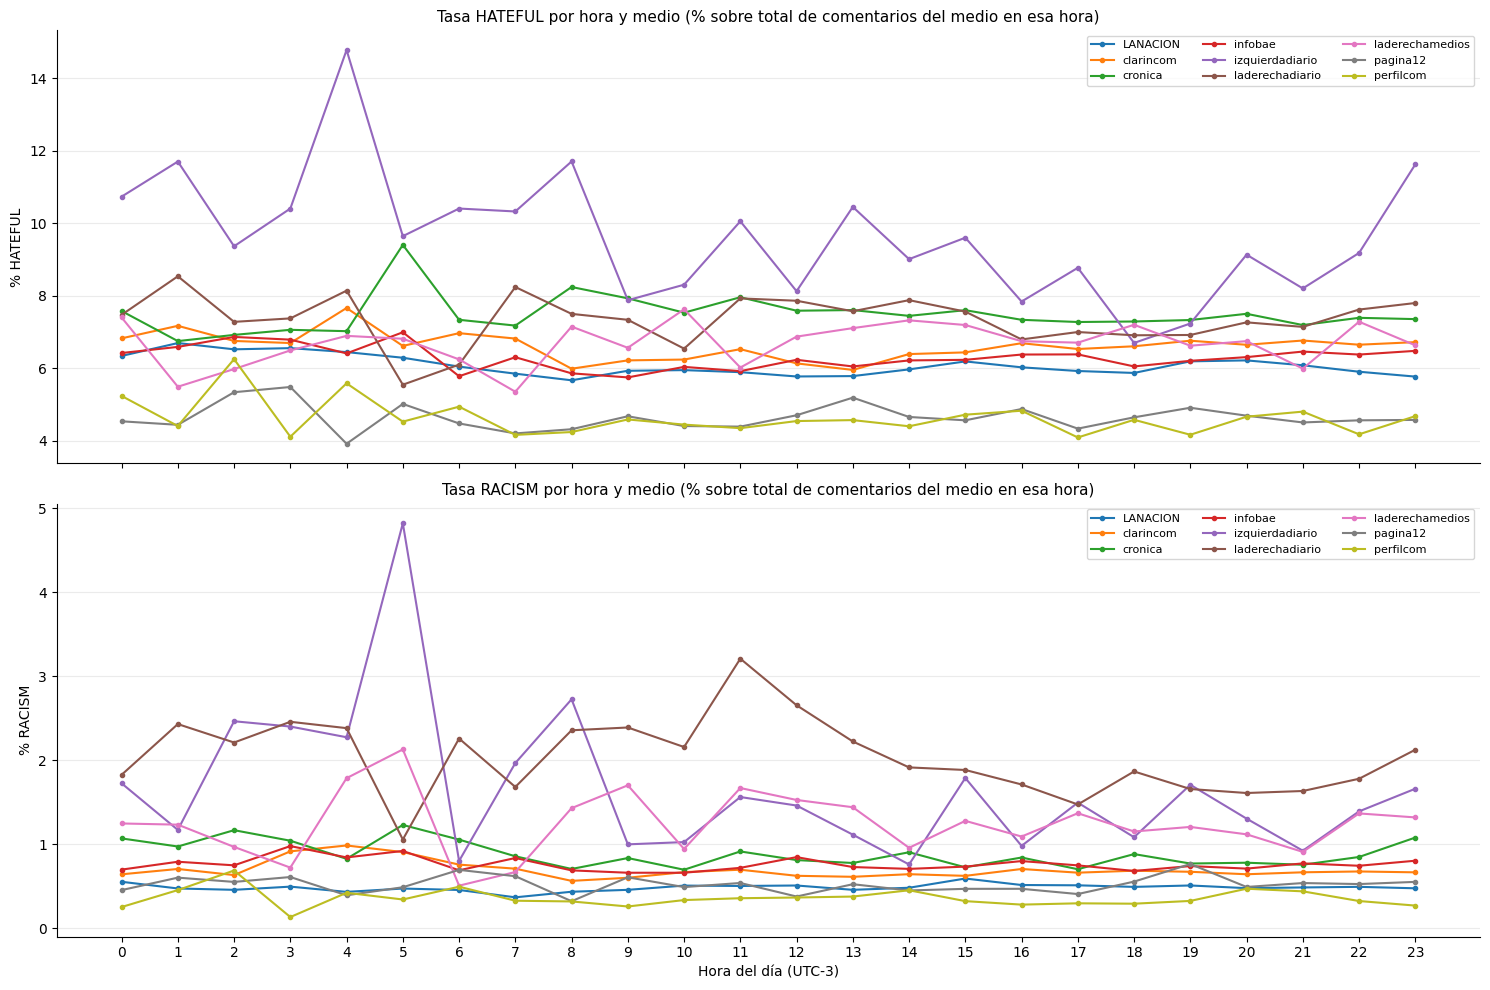

In [54]:

# Tasa % de HATEFUL y RACISM por hora × medio
por_hora_medio = tw_arg.groupby(['medio', 'hora']).agg(
    total=('id', 'count'),
    hateful=('HATEFUL', 'sum'),
    racism=('RACISM', 'sum')
).reset_index()

por_hora_medio['tasa_hateful'] = por_hora_medio['hateful'] / por_hora_medio['total'] * 100
por_hora_medio['tasa_racism']  = por_hora_medio['racism']  / por_hora_medio['total'] * 100

medios = sorted(tw_arg['medio'].unique())
n = len(medios)
palette = dict(zip(medios, sns.color_palette('tab10', n_colors=n)))

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for medio in medios:
    d = por_hora_medio[por_hora_medio['medio'] == medio]
    axes[0].plot(d['hora'], d['tasa_hateful'], label=medio, color=palette[medio], linewidth=1.5, marker='o', markersize=3)
    axes[1].plot(d['hora'], d['tasa_racism'],  label=medio, color=palette[medio], linewidth=1.5, marker='o', markersize=3)

axes[0].set_title('Tasa HATEFUL por hora y medio (% sobre total de comentarios del medio en esa hora)', fontsize=11)
axes[0].set_ylabel('% HATEFUL')
axes[0].legend(fontsize=8, ncol=3, loc='upper right')
axes[0].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[0])

axes[1].set_title('Tasa RACISM por hora y medio (% sobre total de comentarios del medio en esa hora)', fontsize=11)
axes[1].set_ylabel('% RACISM')
axes[1].set_xlabel('Hora del día (UTC-3)')
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=8, ncol=3, loc='upper right')
axes[1].grid(axis='y', alpha=0.25)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()
